## Basic

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('/home/pedrorozin/scripts/python')
import importlib
try:
    import delta_solver_mg_pedro
    importlib.reload(delta_solver_mg_pedro)
    print("Módulo delta_solver_mg_pedro recargado")
except ImportError:
    import delta_solver_mg_pedro
    print("Módulo delta_solver_mg_pedro importado por primera vez")

from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

Módulo delta_solver_mg_pedro recargado


In [3]:
x = np.linspace(0, 2*np.pi, 10000000)
def sin_func(x):
	return np.sin(x)

integral = simpson(sin_func(x), x=x)
print("integral de sin(x) de 0 a 2pi =", integral)



NameError: name 'simpson' is not defined

In [ ]:
#usar cpu
device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


## Funciones para calcular $\sigma_8 (z)$

- $\sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}}^{k_{NL}}P(k,z)|\frac{3j_1(kR)}{kR}|^2k^2dk$
esto sale de Kamionkowski.
 $R=8h^{-1}$, pero entiendo que acá $[k]=h/Mpc$, y yo tengo que meterle sin $h$ al $P_k$ (porque así entran a $\delta $) $\Rightarrow$ hay que hacer cambio de variable $ k'=kh$ (da mal de cualquier forma)

$ \Rightarrow \sigma_8 ^2 (z) = \frac{1}{2 \pi ^2} \int_{k_{hor}'}^{k_{NL}'}P(k',z)|\frac{3j_1(k'R)}{k'R}|^2k'^2dk'/h^3 $

- $\frac{3j_1(kR)}{kR} = W(k)$ es la window function

- $P(k,z) = A_s k^{ns} |\delta_{CLASS}(k,z)|^2$

In [35]:
	# j1= (np.sin(k*R)- np.cos(k*R) *(k*R))/(k*R)**3 
	# W = 3*np.abs(j1)
	# dsigma8_dk = (p_k*(W**2) *k**2) /((h**3)*2*np.pi**2)

	# k, p_k = P_k(z_select=z_select, params=params_default, num_points=num_points)
	# sigma8_z0 = compute_s8(z_select=z_select, params=params_default, num_points=num_points)
	# dsigma8_dk = dsigma8_dk(k, p_k)
	# sigma8_z0 = sigma8(k, dsigma8_dk)

In [36]:
from sympy import fft


params_default = {
	'a': 0.03,
	'h': 0.68,
	'Om_m': 0.3}

def primordial_p_k(k, n_s=0.9665, A_s=2e-9):
	"""Primordial power spectrum P(k) in units of (Mpc/h)^3. 0.005 es el k_pivot"""
	P_k_prim = A_s*(k/0.05)**(n_s-1)*(2*np.pi**2)
	return P_k_prim

def P_k(z_select =1, b_select=0.1, params=params_default, num_points=100):
	"""Power spectrum P(k) in units of (Mpc/h)^3."""
	h = params['h']
	Om_m = params['Om_m']
	khor = 0.006 #1/Mpc 
	k_NL = .2 #1/Mpc
	mis_ks= np.logspace(np.log10(khor), np.log10(k_NL), num_points)
	deltas_k= np.zeros_like(mis_ks)
	for i, k in enumerate(mis_ks):
		solver = DeltaSolver(k=k, h=h, Om_m_0=Om_m, b= b_select)
		khorizon = ft.k_horizon(a_ini= solver.a_0, omega_m=Om_m, omega_r= solver.Om_r_0) #esto es en 1/Mpc
		if k > khor:
			a_mg, delta_mg, _delta_p_mg = solver.solve_delta_mg()
			z_mg = 1/a_mg - 1
			#index donde z=z_select
			idx_z1 = np.argmin(np.abs(z_mg - z_select))
			deltas_k[i] = delta_mg[idx_z1]
	P_k = primordial_p_k(mis_ks)*deltas_k**2
	return mis_ks, P_k


def dsigma8_dk(k, p_k):
	"""Derivada de sigma8^2 respecto a k en z0. Pensada para integrar y tener sigma8."""
	h= params_default['h']
	# k=k*h
	R = 8/h #hay que dividirlo por h porque k entra en unidades de 1/Mpc; R*h=8 necesito
	j1 = spherical_jn(1, k*R)
	W = 3*(j1/(k*R))
	dsigma8_dk = (p_k*(W**2)) /(k*(h**3)*2*np.pi**2)
	return dsigma8_dk


def sigma8(k, _dsigma8_dk):
	"""Sigma8 in z0."""
	# integral = scipy.integrate.quad(lambda k_val: np.interp(k_val, k, _dsigma8_dk), k[0], k[-1])
	#integral = np.trapz(_dsigma8_dk, k)
	integral = simpson(_dsigma8_dk, x=k)
	sigma8 = np.sqrt(integral)
	return sigma8

def compute_s8(z_select=1,b_select=0.1, params=params_default, num_points=100):
	"""Compute sigma8 at a given redshift z_select."""
	k, p_k = P_k(z_select=z_select, b_select = b_select, params=params_default, num_points=num_points)
	ds8_dk = dsigma8_dk(k, p_k)
	sigma8_z0 = sigma8(k, ds8_dk)
	return sigma8_z0

def compute_f_k(z_select, b_select=0.1, params=params_default, num_points=100):
	h = params['h']
	Om_m = params['Om_m']
	solver = DeltaSolver(k=0.1, h=h, Om_m_0=Om_m, b= b_select)
	a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()
	z_mg = 1/a_mg - 1
	idx_z1 = np.argmin(np.abs(z_mg - z_select))
	f_z = 2*np.abs(delta_p_mg[idx_z1]/(delta_mg[idx_z1])*a_mg[idx_z1])
	return f_z

def compute_f(z_select, b_select=0.1, k_min =0.006, k_max= .2, params=params_default, num_points=100):
	"""compute the fourier transform of f_k to get f in real space.
	  the integration is done from k_min to k_max"""
	k, f_k = compute_f_k(z_select=z_select, b_select=b_select, params=params_default, num_points=num_points)
	f_z = fft.ifft(f_k, n=len(k))
	x_fis = fft.ifftfreq(len(k), d=(k[1]-k[0]))

	return f_z

def compute_fs8(sigma8_z0, z_select, b_select=0.1, params=params_default, num_points=100):
	"""Compute f*sigma8 at a given redshift z_select."""
	h = params['h']
	Om_m = params['Om_m']
	solver = DeltaSolver(k=0.1, h=h, Om_m_0=Om_m, b= b_select)
	a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()
	z_mg = 1/a_mg - 1
	idx_z1 = np.argmin(np.abs(z_mg - z_select))
	f_z = np.abs(delta_p_mg[idx_z1]/(delta_mg[idx_z1])*a_mg[idx_z1])
	fs8 = f_z * sigma8_z0
	return fs8


### modificaciones copilot

In [ ]:
from sympy import fft


params_default = {
	'a': 0.03,
	'h': 0.68,
	'Om_m': 0.3}

def primordial_p_k(k, n_s=0.9665, A_s=2e-9):
	"""Primordial power spectrum P(k) in units of (Mpc/h)^3. 0.005 es el k_pivot"""
	P_k_prim = A_s*(k/0.05)**(n_s-1)*(2*np.pi**2)
	return P_k_prim

def P_k(z_select =1, b_select=0.1, params=params_default, num_points=100):
	"""Power spectrum P(k) in units of (Mpc/h)^3."""
	h = params['h']
	Om_m = params['Om_m']
	khor = 0.006 #1/Mpc 
	k_NL = .2 #1/Mpc
	mis_ks= np.logspace(np.log10(khor), np.log10(k_NL), num_points)
	deltas_k= np.zeros_like(mis_ks)
	for i, k in enumerate(mis_ks):
		solver = DeltaSolver(k=k, h=h, Om_m_0=Om_m, b= b_select)
		khorizon = ft.k_horizon(a_ini= solver.a_0, omega_m=Om_m, omega_r= solver.Om_r_0) #esto es en 1/Mpc
		if k > khor:
			a_mg, delta_mg, _delta_p_mg = solver.solve_delta_mg()
			z_mg = 1/a_mg - 1
			#index donde z=z_select
			idx_z1 = np.argmin(np.abs(z_mg - z_select))
			deltas_k[i] = delta_mg[idx_z1]
	P_k = primordial_p_k(mis_ks)*deltas_k**2
	return mis_ks, P_k


def dsigma8_dk(k, p_k):
	"""Derivada de sigma8^2 respecto a k en z0. Pensada para integrar y tener sigma8."""
	h= params_default['h']
	# k=k*h
	R = 8/h #hay que dividirlo por h porque k entra en unidades de 1/Mpc; R*h=8 necesito
	j1 = spherical_jn(1, k*R)
	W = 3*(j1/(k*R))
	dsigma8_dk = (p_k*(W**2)) /(k*(h**3)*2*np.pi**2)
	return dsigma8_dk


def sigma8(k, _dsigma8_dk):
	"""Sigma8 in z0."""
	# integral = scipy.integrate.quad(lambda k_val: np.interp(k_val, k, _dsigma8_dk), k[0], k[-1])
	#integral = np.trapz(_dsigma8_dk, k)
	integral = simpson(_dsigma8_dk, x=k)
	sigma8 = np.sqrt(integral)
	return sigma8

def compute_s8(z_select=1,b_select=0.1, params=params_default, num_points=100):
	"""Compute sigma8 at a given redshift z_select."""
	k, p_k = P_k(z_select=z_select, b_select = b_select, params=params_default, num_points=num_points)
	ds8_dk = dsigma8_dk(k, p_k)
	sigma8_z0 = sigma8(k, ds8_dk)
	return sigma8_z0

def compute_f_k(z_select, b_select=0.1, params=params_default, num_points=100):
	"""Compute f(k,z) = d ln δ / d ln a for each k mode."""
	h = params['h']
	Om_m = params['Om_m']
	khor = 0.006 #1/Mpc 
	k_NL = .2 #1/Mpc
	mis_ks = np.logspace(np.log10(khor), np.log10(k_NL), num_points)
	f_ks = np.zeros_like(mis_ks)
	
	for i, k in enumerate(mis_ks):
		solver = DeltaSolver(k=k, h=h, Om_m_0=Om_m, b=b_select)
		if k > khor:
			a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()
			z_mg = 1/a_mg - 1
			idx_z1 = np.argmin(np.abs(z_mg - z_select))
			
			delta = delta_mg[idx_z1]
			delta_p = delta_p_mg[idx_z1]  # d(delta)/da
			a_here = a_mg[idx_z1]
			
			# f(k,z) = d ln δ / d ln a = (a/δ) * dδ/da
			if np.abs(delta) > 1e-16:
				f_ks[i] = (a_here * delta_p) / delta
			else:
				f_ks[i] = 0.0
	
	return mis_ks, f_ks

def compute_f_real_space(z_select, b_select=0.1, params=params_default, num_points=256):
	"""
	Compute f(x,a) via inverse Fourier transform of f(k,a) according to eq. (4):
	f(x⃗,a) = (1/2π²) ∫ f(k,a) e^{ik⃗·x⃗} k² dk
	
	For spherical symmetry, this becomes:
	f(r,a) = (1/2π²) ∫ f(k,a) (sin(kr)/kr) k² dk
	"""
	# Get f(k) in Fourier space
	k_array, f_k_array = compute_f_k(z_select, b_select, params, num_points)
	
	# Define real space grid
	r_max = 2 * np.pi / k_array[0]  # Nyquist criterion
	r_min = 2 * np.pi / k_array[-1]
	r_array = np.logspace(np.log10(r_min), np.log10(r_max), num_points)
	
	f_real = np.zeros_like(r_array)
	
	# Inverse Fourier transform with spherical symmetry
	for i, r in enumerate(r_array):
		# Integrand: f(k) * sin(kr)/(kr) * k²
		integrand = f_k_array * np.sin(k_array * r) / (k_array * r) * k_array**2
		# Integral over k from k_hor to k_NL
		f_real[i] = (1.0 / (2.0 * np.pi**2)) * simpson(integrand, x=k_array)
	
	return r_array, f_real

def compute_fs8_fourier_method(z_select, b_select=0.1, params=params_default, num_points=256):
	"""
	Compute f*σ₈(z) using the Fourier method according to eq. (6):
	fσ₈(z) = (1/2π²) ∫ f̃(k,a) σ₈(z) e^{ik⃗·x⃗(z)} k² dk
	
	Where σ₈(z) = √[(1/2π²) ∫ P(k,z) |3j₁(kR)/kR|² k² dk]
	"""
	# Get k-space arrays
	k_array, f_k_array = compute_f_k(z_select, b_select, params, num_points)
	k_array_pk, p_k_array = P_k(z_select, b_select, params, num_points)
	
	# Ensure same k grid (interpolate if needed)
	if not np.array_equal(k_array, k_array_pk):
		from scipy.interpolate import interp1d
		f_interp = interp1d(k_array, f_k_array, kind='linear', 
		                   bounds_error=False, fill_value=0.0)
		f_k_array = f_interp(k_array_pk)
		k_array = k_array_pk
	
	# Compute σ₈(z)
	h = params['h']
	R = 8.0 / h
	x = k_array * R
	W = 3.0 * spherical_jn(1, x) / x
	W = np.where(x == 0, 1.0, W)  # Handle x=0 case
	
	# σ₈² = (1/2π²) ∫ P(k,z) W² k² dk
	sigma8_integrand = (1.0 / (2.0 * np.pi**2)) * p_k_array * W**2 * k_array**2
	sigma8_squared = simpson(sigma8_integrand, x=k_array)
	sigma8_z = np.sqrt(np.abs(sigma8_squared))
	
	# Method 1: Weighted average f_eff
	# f_eff = ∫ f(k) I(k) dk / ∫ I(k) dk, where I(k) is the σ₈ integrand
	numerator = simpson(f_k_array * sigma8_integrand, x=k_array)
	f_eff = numerator / sigma8_squared if sigma8_squared > 0 else 0.0
	fs8_method1 = f_eff * sigma8_z
	
	# Method 2: Direct Fourier space integration
	# This is more complex and requires careful treatment of the real space dependence
	# For now, use the weighted average method
	
	return {
		'sigma8': sigma8_z,
		'f_eff': f_eff,
		'fs8': fs8_method1,
		'k_array': k_array,
		'f_k_array': f_k_array,
		'p_k_array': p_k_array
	}

def compute_fs8(sigma8_z0, z_select, b_select=0.1, params=params_default, num_points=100):
	"""Compute f*sigma8 at a given redshift z_select."""
	h = params['h']
	Om_m = params['Om_m']
	solver = DeltaSolver(k=0.1, h=h, Om_m_0=Om_m, b= b_select)
	a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()
	z_mg = 1/a_mg - 1
	idx_z1 = np.argmin(np.abs(z_mg - z_select))
	f_z = np.abs(delta_p_mg[idx_z1]/(delta_mg[idx_z1])*a_mg[idx_z1])
	fs8 = f_z * sigma8_z0
	return fs8

In [ ]:
import funciones_tesis as ft

M = ft.common_settings(h=0.68, omega_m=0.3, A_s=2e-9)
_sigma8=ft.get_sigma8(M)
print("sigma8 from class:", _sigma8)

sigma8 from class: 0.787709890469588


In [39]:
# Test the new Fourier method for computing f*sigma8
print("Testing Fourier method for f*sigma8 computation")
print("="*50)

# Test at z=1
z_test = 1.0
result = compute_fs8_fourier_method(z_test, b_select=0.01, params=params_default, num_points=100)

print(f"At z = {z_test}:")
print(f"σ₈(z) = {result['sigma8']:.4f}")
print(f"f_eff = {result['f_eff']:.4f}")
print(f"f*σ₈(z) = {result['fs8']:.4f}")

# Compare with CLASS result
M = ft.common_settings(h=0.68, omega_m=0.3, A_s=2e-9)
sigma8_class = ft.get_sigma8(M)
print(f"\nComparison:")
print(f"σ₈ from CLASS (z=0): {sigma8_class:.4f}")
print(f"σ₈ from our method (z={z_test}): {result['sigma8']:.4f}")

# Plot f(k) vs k
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.loglog(result['k_array'], np.abs(result['f_k_array']), 'b-', label='|f(k)|')
plt.xlabel('k [1/Mpc]')
plt.ylabel('|f(k)|')
plt.title(f'Growth rate f(k) at z={z_test}')
plt.grid(True)
plt.legend()

# Plot P(k) vs k
plt.subplot(1, 2, 2)
plt.loglog(result['k_array'], result['p_k_array'], 'r-', label='P(k)')
plt.xlabel('k [1/Mpc]')
plt.ylabel('P(k)')
plt.title(f'Power spectrum P(k) at z={z_test}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Testing Fourier method for f*sigma8 computation


KeyboardInterrupt: 

Computing f*σ₈(z) evolution using Fourier method
z=0.00: σ₈=0.0490, f_eff=0.6093, f*σ₈=0.0299
z=0.43: σ₈=0.0377, f_eff=0.8554, f*σ₈=0.0323
z=0.86: σ₈=0.0296, f_eff=0.9909, f*σ₈=0.0293
z=1.29: σ₈=0.0239, f_eff=1.0578, f*σ₈=0.0253
z=1.71: σ₈=0.0199, f_eff=1.0877, f*σ₈=0.0216
z=2.14: σ₈=0.0170, f_eff=1.0978, f*σ₈=0.0186
z=2.57: σ₈=0.0147, f_eff=1.0961, f*σ₈=0.0161
z=3.00: σ₈=0.0130, f_eff=1.0876, f*σ₈=0.0141


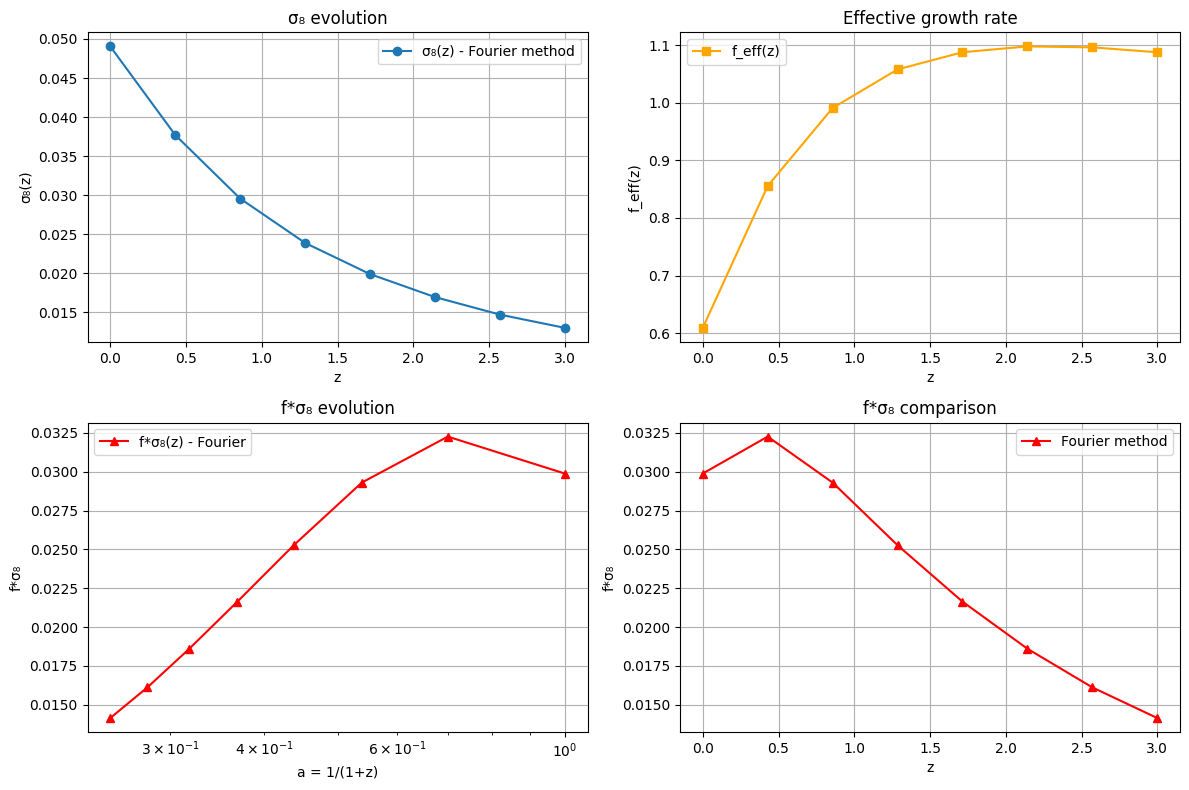


Results saved to fs8_fourier_method.csv


In [ ]:
# Compute f*sigma8(z) over a range of redshifts using the Fourier method
print("Computing f*σ₈(z) evolution using Fourier method")
print("="*50)

z_range = np.linspace(0, 3, 8)  # Reduced points for faster computation
results_fourier = []

for z in z_range:
    result = compute_fs8_fourier_method(z, b_select=0.01, params=params_default, num_points=50)
    results_fourier.append({
        'z': z,
        'a': 1/(1+z),
        'sigma8': result['sigma8'],
        'f_eff': result['f_eff'],
        'fs8': result['fs8']
    })
    print(f"z={z:.2f}: σ₈={result['sigma8']:.4f}, f_eff={result['f_eff']:.4f}, f*σ₈={result['fs8']:.4f}")

# Convert to DataFrame
df_fourier = pd.DataFrame(results_fourier)

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df_fourier['z'], df_fourier['sigma8'], 'o-', label='σ₈(z) - Fourier method')
plt.xlabel('z')
plt.ylabel('σ₈(z)')
plt.title('σ₈ evolution')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(df_fourier['z'], df_fourier['f_eff'], 's-', color='orange', label='f_eff(z)')
plt.xlabel('z')
plt.ylabel('f_eff(z)')
plt.title('Effective growth rate')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df_fourier['a'], df_fourier['fs8'], '^-', color='red', label='f*σ₈(z) - Fourier')
plt.xlabel('a = 1/(1+z)')
plt.ylabel('f*σ₈')
plt.title('f*σ₈ evolution')
plt.xscale('log')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
# Compare with your previous method if available
plt.plot(df_fourier['z'], df_fourier['fs8'], '^-', color='red', label='Fourier method')
plt.xlabel('z')
plt.ylabel('f*σ₈')
plt.title('f*σ₈ comparison')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Save results
df_fourier.to_csv('fs8_fourier_method.csv', index=False)
print(f"\nResults saved to fs8_fourier_method.csv")

Computing f(r,a) via inverse Fourier transform


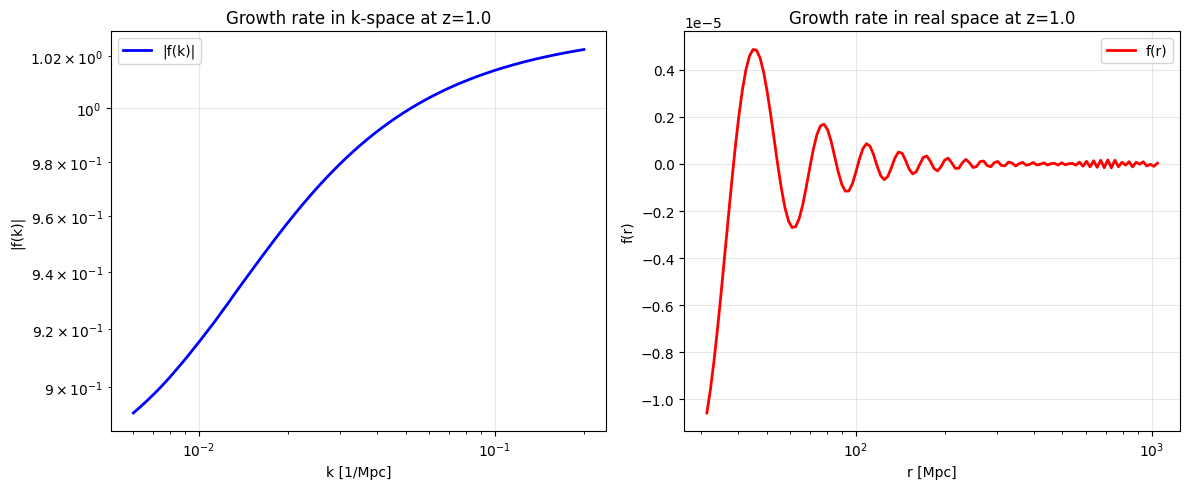

k range: 0.0060 to 0.2000 [1/Mpc]
r range: 31.4159 to 1047.1976 [Mpc]
Max |f(k)|: 1.0225
Max f(r): 0.0000
Min f(r): -0.0000


In [ ]:
# Demonstrate the inverse Fourier transform to real space
print("Computing f(r,a) via inverse Fourier transform")
print("="*50)

z_demo = 1.0
r_array, f_real = compute_f_real_space(z_demo, b_select=0.01, params=params_default, num_points=128)
k_array, f_k = compute_f_k(z_demo, b_select=0.01, params=params_default, num_points=128)

# Plot both k-space and real-space representations
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(k_array, np.abs(f_k), 'b-', linewidth=2, label='|f(k)|')
plt.xlabel('k [1/Mpc]')
plt.ylabel('|f(k)|')
plt.title(f'Growth rate in k-space at z={z_demo}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogx(r_array, f_real, 'r-', linewidth=2, label='f(r)')
plt.xlabel('r [Mpc]')
plt.ylabel('f(r)')
plt.title(f'Growth rate in real space at z={z_demo}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"k range: {k_array[0]:.4f} to {k_array[-1]:.4f} [1/Mpc]")
print(f"r range: {r_array[0]:.4f} to {r_array[-1]:.4f} [Mpc]")
print(f"Max |f(k)|: {np.max(np.abs(f_k)):.4f}")
print(f"Max f(r): {np.max(f_real):.4f}")
print(f"Min f(r): {np.min(f_real):.4f}")

In [ ]:

s8_z1 = compute_s8(z_select=0, b_select=0.01, params=params_default, num_points=20)
print("sigma8(z=0) =", s8_z1)

sigma8(z=0) = 0.0872099964941906


y min, max: 0.005999999999999999 2.0


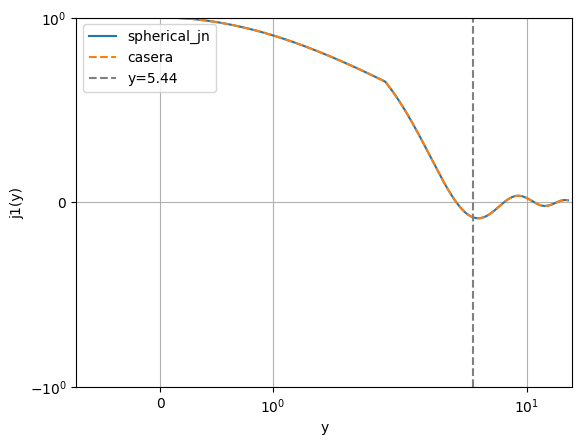

In [ ]:
h= params_default['h']
khor= 0.006/h
k_NL= 2/h
y= np.logspace(np.log10(khor), np.log10(k_NL), 100000)*8*h
print("y min, max:", y.min()/8, y.max()/8)
j1 = 3*spherical_jn(1, y)/y
_j1 = 3*(np.sin(y)- np.cos(y)*y)/y**3
plt.plot(y, j1, label='spherical_jn')
plt.plot(y, _j1, '--', label='casera')
plt.yscale('symlog')
#vline in y=8
#y where y/(8*h)=1
index = np.argmin(np.abs(y/h - 8))
plt.axvline(x=y[index], color='gray', linestyle='--', label=f'y={y[index]:.2f}')
plt.legend()
plt.xscale('symlog')
plt.yscale('symlog')
plt.ylim(-1, 1)
plt.xlabel('y')
plt.ylabel('j1(y)')
# plt.title('Spherical Bessel function of the first kind, order 1')
plt.grid()
plt.show()

### funciones de chatGPT

In [ ]:
import numpy as np
from scipy.special import spherical_jn
from scipy.integrate import simpson

# --- helpers: ventana ---
def window_W(k, h, R_phys=None):
    """
    Window function W(kR) with R = 8/h (Mpc/h -> physical Mpc if k in 1/Mpc).
    We keep R_phys optional: if provided it's used directly.
    """
    if R_phys is None:
        R = 8.0 / h   # your convention: R in Mpc (if k in 1/Mpc)
    else:
        R = R_phys
    x = k * R
    # spherical_jn(1,x) = j1(x)
    # avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        j1 = spherical_jn(1, x)
        W = 3.0 * (j1 / x)
        W = np.where(x == 0, 1.0, W)   # límite x->0, W->1
    return W

# --- calcula f(k,z) en una grilla de k usando DeltaSolver ---
def compute_f_k_array(z_select, mis_ks, b_select=0.1, params=params_default):
    """
    Devuelve arrays (mis_ks, fks) donde fks = d ln delta / d ln a = a * (d delta / da) / delta
    """
    h = params['h']
    Om_m = params['Om_m']
    fks = np.zeros_like(mis_ks)
    # itera sobre ks (podés vectorizar si tu solver permite)
    for i, k in enumerate(mis_ks):
        solver = DeltaSolver(k=k, h=h, Om_m_0=Om_m, b=b_select)
        a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()  # d(delta)/da esperado
        z_mg = 1.0 / a_mg - 1.0
        idx_z = np.argmin(np.abs(z_mg - z_select))
        delta = delta_mg[idx_z]
        delta_p = delta_p_mg[idx_z]
        # growth rate f(k,z) = d ln delta / d ln a = (a/δ) dδ/da
        a_here = a_mg[idx_z]
        # protecciones numéricas:
        if np.abs(delta) < 1e-16:
            fks[i] = 0.0
        else:
            fks[i] = (a_here * delta_p) / delta
    return mis_ks, fks

# --- f_eff y f*sigma8 usando la ponderación por contribución a sigma8^2 ---
def compute_f_eff_and_fs8(z_select, b_select=0.1, params=params_default, num_points=200,
                          kmin=0.0005, kmax=1.0, use_Pk_from_function=True):
    """
    1) Construye una grilla de k (si P_k te la da, la usamos).
    2) Calcula P(k,z) (tu función P_k ya lo hace), calcula f(k,z) con compute_f_k_array.
    3) Calcula sigma8^2 usando integrand I(k) = (1/2pi^2) P(k) W^2 k^2
       y f_eff = integral f(k) I(k) / integral I(k)
    4) Retorna f_eff, sigma8 (sqrt), fs8 = f_eff * sigma8
    """
    h = params['h']
    # obtener P(k,z) y ks:
    if use_Pk_from_function:
        ks, Pks = P_k(z_select=z_select, b_select=b_select, params=params, num_points=num_points)
    else:
        ks = np.logspace(np.log10(kmin), np.log10(kmax), num_points)
        # deberías llenar Pks con tu propia función si no usás P_k
        ks, Pks = P_k(z_select=z_select, b_select=b_select, params=params, num_points=num_points)

    # ventana
    W = window_W(ks, h=h, R_phys=None)

    # integrand I(k)
    integrand = (1.0 / (2.0 * np.pi**2)) * Pks * (W**2) * (ks**2)

    # sigma8^2
    sigma8_sq = simpson(integrand, x=ks)
    sigma8 = np.sqrt(np.abs(sigma8_sq))

    # compute f(k) on same ks
    _, fks = compute_f_k_array(z_select=z_select, mis_ks=ks, b_select=b_select, params=params)

    # numerator integral for f_eff
    numerator = simpson(fks * integrand, x=ks)
    # avoid division by zero:
    if sigma8_sq <= 0:
        f_eff = 0.0
    else:
        f_eff = numerator / sigma8_sq

    fs8 = f_eff * sigma8
    return {'ks': ks, 'Pks': Pks, 'fks': fks, 'sigma8': sigma8, 'f_eff': f_eff, 'fs8': fs8,
            'sigma8_sq': sigma8_sq}

# --- alternativa RMS (opcional) ---
def compute_fs8_via_rms(z_select, b_select=0.1, params=params_default, num_points=200):
    """
    fsigma8 via sqrt( (1/2pi^2) integral f(k)^2 P(k) W^2 k^2 dk )
    """
    h = params['h']
    ks, Pks = P_k(z_select=z_select, b_select=b_select, params=params, num_points=num_points)
    W = window_W(ks, h=h)
    _, fks = compute_f_k_array(z_select=z_select, mis_ks=ks, b_select=b_select, params=params)
    integrand = (1.0 / (2.0 * np.pi**2)) * (fks**2) * Pks * (W**2) * (ks**2)
    sigma8_f_sq = simpson(integrand, x=ks)
    fs8_rms = np.sqrt(np.abs(sigma8_f_sq))
    return {'ks': ks, 'Pks': Pks, 'fks': fks, 'fs8_rms': fs8_rms, 'sigma8_f_sq': sigma8_f_sq}


z=0.000  sigma8=0.0484  f_eff=0.6092  fs8=0.0295
z=0.333  sigma8=0.0395  f_eff=0.8098  fs8=0.0320
z=0.667  sigma8=0.0324  f_eff=0.9412  fs8=0.0305
z=1.000  sigma8=0.0270  f_eff=1.0190  fs8=0.0276
z=1.333  sigma8=0.0231  f_eff=1.0622  fs8=0.0245
z=1.667  sigma8=0.0200  f_eff=1.0852  fs8=0.0217
z=2.000  sigma8=0.0176  f_eff=1.0956  fs8=0.0192
z=2.333  sigma8=0.0156  f_eff=1.0975  fs8=0.0172
z=2.667  sigma8=0.0141  f_eff=1.0938  fs8=0.0154
z=3.000  sigma8=0.0128  f_eff=1.0867  fs8=0.0139


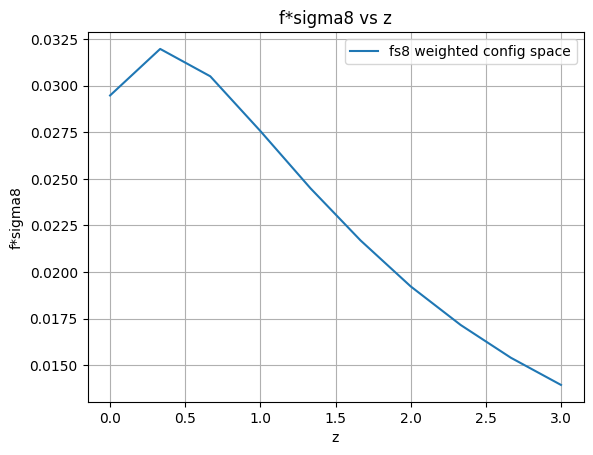

In [ ]:
mis_zs = np.linspace(0, 3, 10)
rows = []
for z in mis_zs:
    out = compute_f_eff_and_fs8(z_select=z, b_select=0.01, params=params_default, num_points=10)
    print(f"z={z:.3f}  sigma8={out['sigma8']:.4f}  f_eff={out['f_eff']:.4f}  fs8={out['fs8']:.4f}")
    rows.append({'z': z, 'sigma8': out['sigma8'], 'f_eff': out['f_eff'], 'fs8': out['fs8']})

df_fs8 = pd.DataFrame(rows)
df_fs8.to_csv('fs8_MG_weighted_config_space.csv', index=False)

#plot fs8 vs z


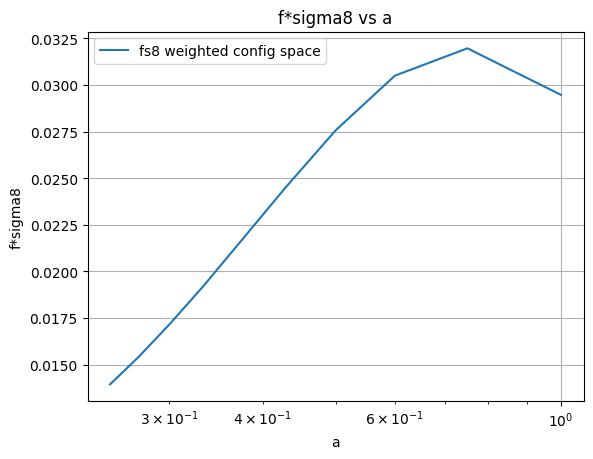

In [ ]:
df_fs8['a'] = 1/(1+df_fs8['z'])
plt.plot(df_fs8['a'], df_fs8['fs8'], label='fs8 weighted config space')
plt.xlabel('a')
plt.ylabel('f*sigma8')
plt.xscale('log')
plt.title('f*sigma8 vs a')
plt.legend()
plt.grid()
plt.show()

## $\sigma_8 (z)$

In [3]:
import funciones_tesis as ft
import importlib
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 100)  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)
a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
z_mg = 1/a_mg - 1

#save arrays in df
df = pd.DataFrame(
	{
		'a': a_mg,
		'z': z_mg,
		'delta_mg': delta_mg
		'delta_p_mg': delta_p_mg
		

	}
)

VectorizedDeltaSolver usando: cuda
Resolviendo 100 valores de k en paralelo con 16 procesos...


Resolución paralela completada.
Resolviendo LCDM para 100 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.
Resolución paralela LCDM completada.


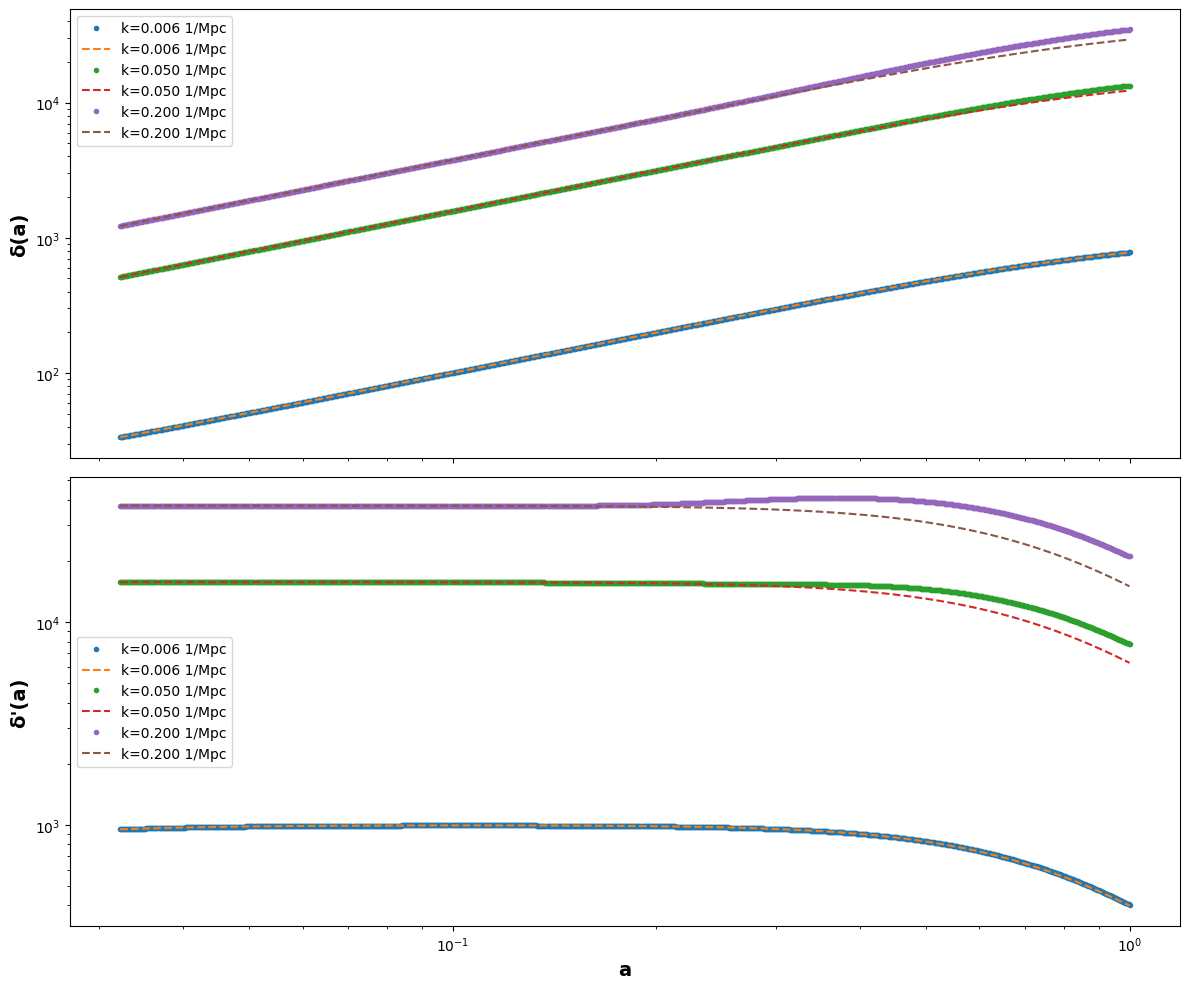

In [62]:

#plot 3 delta_mg vs a_mg for 3 different ks
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for i, k in enumerate([0.006, 0.05, 0.2]):
	idx = np.argmin(np.abs(mis_ks - k))
	axs[0].plot(a_mg, np.abs(delta_mg[idx, :]), '.', label=f'k={k:.3f} 1/Mpc')
	axs[0].plot(a_LCDM, np.abs(delta_LCDM[idx, :]), '--', label=f'k={k:.3f} 1/Mpc')
	axs[1].plot(a_mg, np.abs(delta_p_mg[idx, :]), '.', label=f'k={k:.3f} 1/Mpc')
	axs[1].plot(a_LCDM, np.abs(delta_p_LCDM[idx, :]), '--', label=f'k={k:.3f} 1/Mpc')
axs[0].legend()
axs[1].legend()
axs[0].set_xscale('log')
axs[1].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('a', fontsize=14, fontweight='bold')
axs[0].set_ylabel('δ(a)', fontsize=14, fontweight='bold')
axs[1].set_ylabel("δ'(a)", fontsize=14, fontweight='bold')
# axs[0].set_title('Matter density contrast δ_mg(a) for different k modes')
# axs[1].set_title('Matter density contrast δ_LCDM(a) for different k modes')
plt.tight_layout()
plt.show()


In [65]:
#compute sigma8
sigma8_lcdm = solver.compute_sigma8_vectorized(deltas = delta_LCDM)

In [72]:
sigma8_mg = solver.compute_sigma8_vectorized(deltas = delta_mg)

In [86]:
#idx where z = 3
z_LCDM = 1/a_LCDM - 1
idx_lcdm = np.argmin(np.abs(z_LCDM - 3))
idx_mg = np.argmin(np.abs(z_mg - 3))
sigma8_lcdm_z3 = sigma8_lcdm[idx_lcdm:]
sigma8_mg_z3 = sigma8_mg[idx_mg:]
z_idxs_LCDM = z_LCDM[idx_lcdm:]
z_idxs_MG = z_mg[idx_mg:]
print('sigma8(z=0) LCDM:', sigma8_lcdm[-1])
print('sigma8(z=0) MG:', sigma8_mg[-1])

sigma8(z=0) LCDM: 0.1592665612238562
sigma8(z=0) MG: 0.1855763848866624


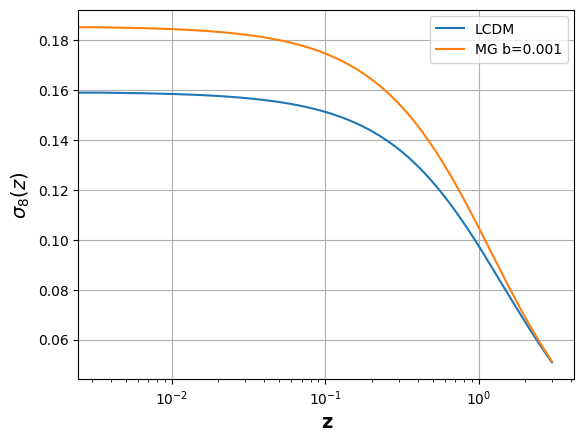

In [87]:
#plot sigma 8 vs z
plt.plot(z_idxs_LCDM, sigma8_lcdm_z3, label='LCDM')
plt.plot(z_idxs_MG, sigma8_mg_z3, label='MG b=0.001')
plt.xlabel('z', fontsize=14, fontweight='bold')
plt.ylabel('$\sigma_8(z)$', fontsize=14, fontweight='bold')
plt.xscale('log')
# plt.yscale('log')
# plt.title('sigma8(z) vs z')
plt.legend()
plt.grid()
plt.show()

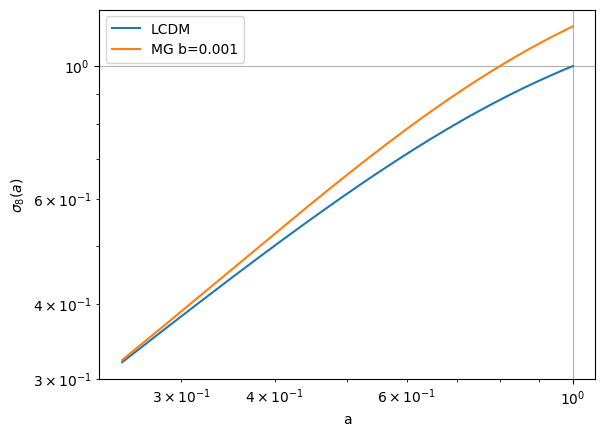

In [78]:
#plot sigma 8 vs a
plt.plot(a_LCDM[idx_lcdm:], sigma8_lcdm[idx_lcdm:]*2*np.pi, label='LCDM')
plt.plot(a_mg[idx_mg:], sigma8_mg[idx_mg:]*2*np.pi, label='MG b=0.001')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('a')
plt.ylabel('$\sigma_8(a)$')
# plt.title('sigma8 vs a')
plt.legend()
plt.grid()

In [90]:
#save in csv sigma8, z and a
import pandas as pd
df_sigma8 = pd.DataFrame({'a_LCDM': a_LCDM[idx_lcdm:], 'z_LCDM': z_idxs_LCDM, 'sigma8_LCDM': sigma8_lcdm_z3,
						  'a_MG': a_mg[idx_mg:], 'z_MG': z_idxs_MG, 'sigma8_MG': sigma8_mg_z3})
df_sigma8.to_csv('sigma8_vs_z.csv', index=False)

## $f\sigma_8(z)$

In [ ]:
import funciones_tesis as ft
import importlib
import sys
sys.path.append('../python/')
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt

In [5]:
mis_ks = np.logspace(np.log10(0.006), np.log10(0.2), 100)  # k en 1/Mpc
solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)
a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel()
a_LCDM, delta_LCDM, delta_p_LCDM = solver.solve_delta_lcdm_vectorized_parallel()
z_mg = 1/a_mg - 1

VectorizedDeltaSolver usando: cuda
Resolviendo 100 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo LCDM para 100 valores de k en paralelo con 16 procesos...
Resolución paralela LCDM completada.


### $\Lambda CDM$
Acá esto coincide con: $f\sigma_8(z) = \delta(z)/ \delta'(z=0) \sigma 8(z=0)$

In [1]:
# Recargar módulo después de la corrección
import importlib
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
print("Módulo recargado después de corregir el error de tensor GPU->CPU")

NameError: name 'delta_solver_mg_pedro' is not defined

In [16]:
# Recrear el solver con el módulo actualizado
solver = VectorizedDeltaSolver(k_array=mis_ks, h=0.68, Om_m_0=0.3, b=0.001)
print("Solver recreado con la corrección")

VectorizedDeltaSolver usando: cuda
Solver recreado con la corrección


In [17]:
_k_array_mg, z_f_k_mg, f_k_mg = solver.compute_f_k_vectorized(a_vec=a_mg, delta=delta_mg, delta_p=delta_p_mg)
f_z = solver.compute_f_with_f_k(z_vec=z_f_k_mg, f_k_array=f_k_mg)


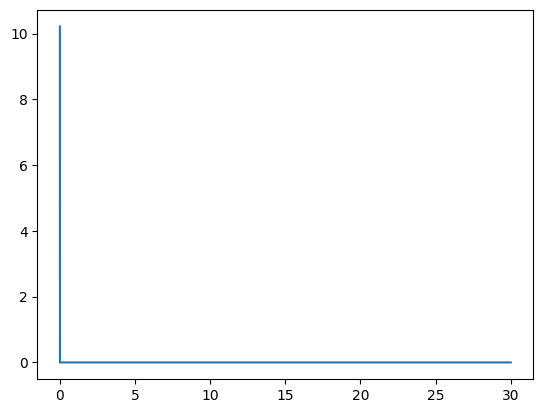

In [32]:
plt.plot(z_f_k_mg, f_z)

In [27]:
df_sigma8 = pd.read_csv('sigma8_vs_z.csv')
z_df = df_sigma8['z_MG'].values
sigma8_mg = np.array(df_sigma8['sigma8_MG'].values)
sigma8_lcdm = np.array(df_sigma8['sigma8_LCDM'].values)
idx_z3= np.argmin(np.abs(z_f_k_mg - 3))
f_z3 = f_z[idx_z3:]
f_s8 = f_z3 * sigma8_mg

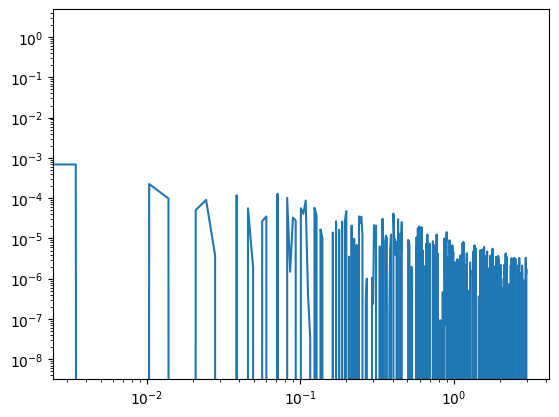

In [31]:
plt.plot(z_df, f_s8)
#logscale
plt.xscale('log')
plt.yscale('log')

## Cosas que tardan mucho en correr:

sigma8(z=0.0) = 2.185322084830117, iteracion 0/10
sigma8(z=0.3333333333333333) = 1.780482051918923, iteracion 1/10
sigma8(z=0.6666666666666666) = 1.4608253637402027, iteracion 2/10
sigma8(z=1.0) = 1.2191513766534916, iteracion 3/10
sigma8(z=1.3333333333333333) = 1.0387859290585808, iteracion 4/10
sigma8(z=1.6666666666666665) = 0.8999226685237416, iteracion 5/10
sigma8(z=2.0) = 0.7892710301309013, iteracion 6/10
sigma8(z=2.333333333333333) = 0.7019227275536396, iteracion 7/10
sigma8(z=2.6666666666666665) = 0.6311564763281036, iteracion 8/10
sigma8(z=3.0) = 0.5740733051441228, iteracion 9/10


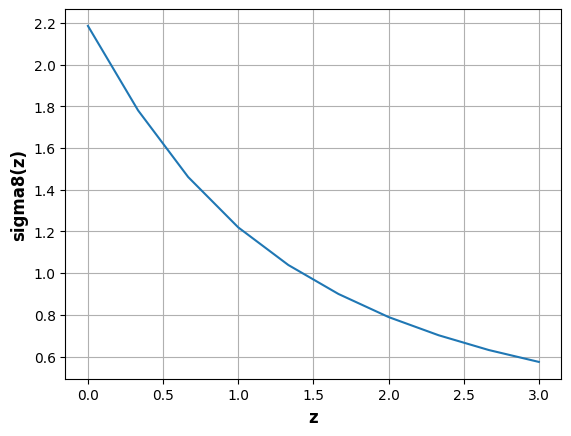

In [5]:
mis_zs = np.linspace(0, 3, 10)
sigmas8 = []
for i,z in enumerate(mis_zs):
	s8_z = compute_s8(z_select=z, params=params_default, num_points=100)
	sigmas8.append(s8_z)
	print(f"sigma8(z={z}) = {s8_z}, iteracion {i}/{len(mis_zs)}")
	

df = pd.DataFrame({'z': mis_zs, 'sigma8': sigmas8})
df.to_csv('prueba3_sigma8_MG_with_primordial_pk.csv', index=False)
df = pd.read_csv('prueba3_sigma8_MG_with_primordial_pk.csv')
mis_zs = df['z'].values
sigmas8 = df['sigma8'].values #porque sigma8
plt.plot(mis_zs, sigmas8)
plt.xlabel("z", fontweight='bold', fontsize=12)
plt.ylabel("sigma8(z)", fontweight='bold', fontsize=12)
plt.grid()
plt.show()

In [ ]:
# #save to csv
# df = pd.DataFrame({'z': mis_zs, 'sigma8': sigmas8})
# df.to_csv('sigma8_MG_with_primordial_pk.csv', index=False)
# #!/usr/bin/env python3

In [6]:
fs8s = []
f=[]
h= params_default['h']
#load df
df_results= pd.read_csv('prueba3_sigma8_MG_with_primordial_pk.csv')
mis_zs = df_results['z'].values
sigmas8 = df_results['sigma8'].values /(h**3)
for z, s8 in zip(mis_zs, sigmas8):
	fs8 = compute_fs8(s8, z, params=params_default)
	fs8s.append(fs8)
	print(f"f*sigma8(z={z}) = {fs8}")
	_f = compute_fs8(np.ones(len(mis_zs)), z, params=params_default)
	f.append(_f)


f*sigma8(z=0.0) = 4.286285512852189
f*sigma8(z=0.3333333333333333) = 4.609718612872439
f*sigma8(z=0.6666666666666666) = 4.383606021430404
f*sigma8(z=1.0) = 3.964721703300543
f*sigma8(z=1.3333333333333333) = 3.5323747015160407
f*sigma8(z=1.6666666666666663) = 3.1390960856624033
f*sigma8(z=2.0) = 2.79256706446491
f*sigma8(z=2.333333333333333) = 2.5003110523016066
f*sigma8(z=2.6666666666666665) = 2.252336513821392
f*sigma8(z=3.0) = 2.045358162901316


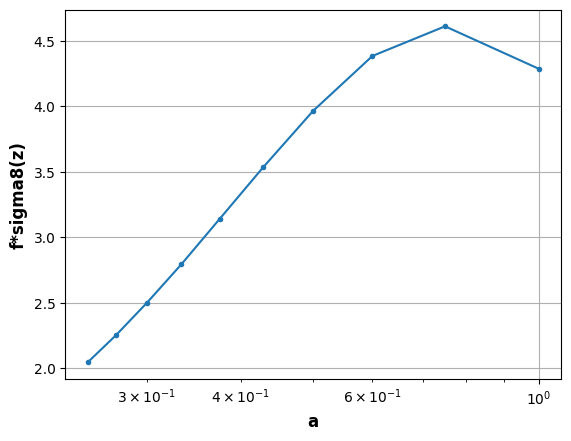

In [8]:
mis_a = 1/(1+np.array(mis_zs))
plt.plot(mis_a, fs8s, '.-')
plt.xlabel("a", fontweight='bold', fontsize=12)
plt.ylabel("f*sigma8(z)", fontweight='bold', fontsize=12)
plt.xscale('log')
plt.grid()
plt.show()

## Versión Vectorizada con GPU - Nueva Implementación

La nueva clase `VectorizedDeltaSolver` permite calcular múltiples valores de k simultáneamente, optimizando el cálculo de f*σ₈.

In [27]:
# Importar la nueva clase vectorizada
# Primero recarguemos el módulo para obtener la nueva clase
import importlib
import sys
sys.path.append('/home/pedrorozin/scripts/python')

# Recargar el módulo para obtener la nueva clase
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, calculate_fs8_vectorized


In [29]:
# Probar la nueva clase vectorizada
print("Probando VectorizedDeltaSolver con GPU...")
print("="*50)

# Configurar parámetros de prueba
params_test = {
    'h': 0.68,
    'Om_m': 0.3
}

# Crear array de k's para probar (pequeño para la demostración)
k_test = np.logspace(np.log10(0.006), np.log10(0.2), 3)  # 20 k's para prueba rápida
b_test = 0.01

print(f"Probando con {len(k_test)} valores de k")
print(f"Rango de k: {k_test[0]:.4f} a {k_test[-1]:.4f} [1/Mpc]")

# Crear el solver vectorizado
solver_vec = VectorizedDeltaSolver(
    k_array=k_test,
    Om_m_0=params_test['Om_m'],
    h=params_test['h'],
    b=b_test,
    use_gpu=True  # Intentar usar GPU
)

print(f"Solver creado. Dispositivo: {solver_vec.device}")
print(f"Número de k's: {solver_vec.n_k}")

Probando VectorizedDeltaSolver con GPU...
Probando con 3 valores de k
Rango de k: 0.0060 a 0.2000 [1/Mpc]
VectorizedDeltaSolver usando: cuda
Solver creado. Dispositivo: cuda
Número de k's: 3


In [30]:
# Probar las condiciones iniciales vectorizadas
print("Probando condiciones iniciales vectorizadas...")
import time

start_time = time.time()
delta_ini, delta_p_ini = solver_vec.condiciones_iniciales_vectorized()
ci_time = time.time() - start_time

print(f"Condiciones iniciales calculadas en {ci_time:.3f} segundos")
print(f"Forma de delta_ini: {delta_ini.shape}")
print(f"Forma de delta_p_ini: {delta_p_ini.shape}")
print(f"Rango delta_ini: [{delta_ini.min():.6f}, {delta_ini.max():.6f}]")
print(f"Rango delta_p_ini: [{delta_p_ini.min():.6f}, {delta_p_ini.max():.6f}]")

# Mostrar algunos valores
print("\nPrimeros 5 valores:")
for i in range(min(5, len(k_test))):
    print(f"k={k_test[i]:.4f}: delta_ini={delta_ini[i]:.6f}, delta_p_ini={delta_p_ini[i]:.6f}")

Probando condiciones iniciales vectorizadas...
Condiciones iniciales calculadas en 0.008 segundos
Forma de delta_ini: (3,)
Forma de delta_p_ini: (3,)
Rango delta_ini: [-1219.881592, -33.395760]
Rango delta_p_ini: [-37579.515625, -948.582825]

Primeros 5 valores:
k=0.0060: delta_ini=-33.395760, delta_p_ini=-948.582825
k=0.0346: delta_ini=-397.656769, delta_p_ini=-12242.024414
k=0.2000: delta_ini=-1219.881592, delta_p_ini=-37579.515625


In [31]:
#plot delta vs a for all k
t_ini_vec = time.time()
a_mg, delta_mg, delta_p_mg = solver_vec.solve_delta_mg_vectorized()
t_vec = time.time() - t_ini_vec
print(f"\nEvolución completa calculada en {t_vec:.3f} segundos")
print(f"Forma de a_mg: {a_mg.shape}")
print(f"Forma de delta_mg: {delta_mg.shape}")
print(f"Forma de delta_p_mg: {delta_p_mg.shape}")
t_ini_paral = time.time()
a_mg_paral, delta_mg_paral, delta_p_mg_paral = solver_vec.solve_delta_mg_vectorized_parallel(n_jobs=16)
t_paral = time.time() - t_ini_paral
print(f"\nEvolución completa en paralelo calculada en {t_paral:.3f} segundos")
print(f"Forma de a_mg_paral: {a_mg_paral.shape}")
print(f"Forma de a_mg_paral: {delta_mg_paral.shape}")



Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada.

Evolución completa calculada en 7.562 segundos
Forma de a_mg: (1000,)
Forma de delta_mg: (3, 1000)
Forma de delta_p_mg: (3, 1000)
Resolviendo 3 valores de k en paralelo con 16 procesos...
Resolución paralela completada.

Evolución completa en paralelo calculada en 2.584 segundos
Forma de a_mg_paral: (1000,)
Forma de a_mg_paral: (3, 1000)


In [5]:
import delta_solver_mg_pedro
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

In [24]:
solver = DeltaSolver(k=0.2,
					 Om_m_0=params_test['Om_m'],
    				h=params_test['h'],
    				b=b_test)
a_mg, delta_mg, delta_p_mg = solver.solve_delta_mg()
print((a_mg))
print(len(a_mg), len(delta_mg), len(delta_p_mg))

[0.03225806 0.03236914 0.0324806  0.03259244 0.03270467 0.03281728
 0.03293028 0.03304367 0.03315745 0.03327162 0.03338619 0.03350115
 0.03361651 0.03373226 0.03384841 0.03396496 0.03408191 0.03419927
 0.03431703 0.03443519 0.03455377 0.03467275 0.03479214 0.03491194
 0.03503215 0.03515278 0.03527382 0.03539528 0.03551716 0.03563946
 0.03576218 0.03588532 0.03600888 0.03613287 0.03625729 0.03638214
 0.03650741 0.03663312 0.03675926 0.03688584 0.03701285 0.03714029
 0.03726818 0.03739651 0.03752528 0.03765449 0.03778415 0.03791425
 0.0380448  0.0381758  0.03830726 0.03843916 0.03857152 0.03870433
 0.03883761 0.03897134 0.03910553 0.03924018 0.0393753  0.03951088
 0.03964693 0.03978345 0.03992044 0.0400579  0.04019583 0.04033424
 0.04047312 0.04061248 0.04075233 0.04089265 0.04103346 0.04117475
 0.04131653 0.0414588  0.04160155 0.0417448  0.04188854 0.04203278
 0.04217751 0.04232274 0.04246848 0.04261471 0.04276145 0.04290869
 0.04305644 0.04320469 0.04335346 0.04350274 0.04365254 0.0438

In [ ]:

a_mg_parallel, delta_mg_parallel, delta_p_mg_parallel = solver_vec.solve_delta_mg_vectorized_parallel(n_jobs=16)
a_mg_vec, delta_mg_vec, delta_p_mg_vec = solver_vec.solve_delta_mg_vectorized()
print(len(a_mg_parallel), len(delta_mg_parallel), len(delta_p_mg_parallel))
print(len(a_mg_vec), len(delta_mg_vec), len(delta_p_mg_vec))

Resolviendo 3 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución paralela completada.
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada.
1000 3 3
1000 3 3
Resolución completada.
1000 3 3
1000 3 3


In [16]:
print(f"Longitud de a_mg: {len(a_mg)}")
print(f"Longitud de a_mg_vec: {len(a_mg_vec)}")
print(f"Longitud de a_mg_parallel: {len(a_mg_parallel)}")
print(f"Primeros 5 valores de a_mg: {a_mg[:5]}")
print(f"¿Primer punto duplicado? {a_mg[0] == a_mg[1]}")

Longitud de a_mg: 1001
Longitud de a_mg_vec: 1001
Longitud de a_mg_parallel: 1001
Primeros 5 valores de a_mg: [0.03225806 0.03225806 0.03236914 0.0324806  0.03259244]
¿Primer punto duplicado? False


In [17]:
print(f"Primer punto: {a_mg[0]:.15f}")
print(f"Segundo punto: {a_mg[1]:.15f}")
print(f"Diferencia: {abs(a_mg[0] - a_mg[1]):.2e}")
print(f"¿Son prácticamente iguales? {abs(a_mg[0] - a_mg[1]) < 1e-10}")

# Veamos qué pasa si reconstrusimos el array manualmente
a_ini = solver.a_0
a_fin = 1.0
num_points = 1000

print(f"\nReconstrucción manual con num_points={num_points}:")
print(f"a_ini = {a_ini:.15f}")
print(f"a_fin = {a_fin:.15f}")

# El array original que se genera
a_original = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points)
print(f"Array original tiene {len(a_original)} puntos")
print(f"Primer punto original: {a_original[0]:.15f}")
print(f"Último punto original: {a_original[-1]:.15f}")

# Después del filtro
a_filtered = a_original[(a_original > a_ini) & (a_original < a_fin)]
print(f"Array filtrado tiene {len(a_filtered)} puntos")

# Después de las inserciones
a_with_endpoints = np.insert(a_filtered, 0, a_ini)
a_final = np.insert(a_with_endpoints, len(a_with_endpoints), a_fin)
print(f"Array final tiene {len(a_final)} puntos")
print(f"Primeros 3 puntos del array final: {a_final[:3]}")

Primer punto: 0.032258064516129
Segundo punto: 0.032258064516129
Diferencia: 6.94e-18
¿Son prácticamente iguales? True

Reconstrucción manual con num_points=1000:
a_ini = 0.032258064516129
a_fin = 1.000000000000000
Array original tiene 1000 puntos
Primer punto original: 0.032258064516129
Último punto original: 1.000000000000000
Array filtrado tiene 999 puntos
Array final tiene 1001 puntos
Primeros 3 puntos del array final: [0.03225806 0.03225806 0.03236914]


In [20]:
# Recargar el módulo con las correcciones
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

# Recrear los solvers con los parámetros actuales
solver = DeltaSolver(k=0.2,
					 Om_m_0=params_test['Om_m'],
    				h=params_test['h'],
    				b=b_test)
    				
solver_vec = VectorizedDeltaSolver(
    k_array=k_test,
    Om_m_0=params_test['Om_m'],
    h=params_test['h'],
    b=b_test,
    use_gpu=True
)

print("Módulo recargado y solvers recreados.")

VectorizedDeltaSolver usando: cuda
Módulo recargado y solvers recreados.


In [21]:
# Probar las correcciones
print("Probando la corrección con solve_delta_mg()...")
a_mg_corregido, delta_mg_corregido, delta_p_mg_corregido = solver.solve_delta_mg(num_points=1000)
print(f"Longitud de a_mg_corregido: {len(a_mg_corregido)}")
print(f"Primeros 5 valores: {a_mg_corregido[:5]}")
print(f"¿Primer punto duplicado? {a_mg_corregido[0] == a_mg_corregido[1]}")
print(f"Diferencia entre primer y segundo punto: {abs(a_mg_corregido[0] - a_mg_corregido[1]):.2e}")

print("\nProbando la corrección con solve_delta_mg_vectorized()...")
a_mg_vec_corregido, delta_mg_vec_corregido, delta_p_mg_vec_corregido = solver_vec.solve_delta_mg_vectorized(num_points=1000)
print(f"Longitud de a_mg_vec_corregido: {len(a_mg_vec_corregido)}")
print(f"Primeros 5 valores: {a_mg_vec_corregido[:5]}")
print(f"¿Primer punto duplicado? {a_mg_vec_corregido[0] == a_mg_vec_corregido[1]}")
print(f"Diferencia entre primer y segundo punto: {abs(a_mg_vec_corregido[0] - a_mg_vec_corregido[1]):.2e}")

Probando la corrección con solve_delta_mg()...
Longitud de a_mg_corregido: 1000
Primeros 5 valores: [0.03225806 0.03236914 0.0324806  0.03259244 0.03270467]
¿Primer punto duplicado? False
Diferencia entre primer y segundo punto: 1.11e-04

Probando la corrección con solve_delta_mg_vectorized()...
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada.
Longitud de a_mg_vec_corregido: 1000
Primeros 5 valores: [0.03225806 0.03236914 0.0324806  0.03259244 0.03270467]
¿Primer punto duplicado? False
Diferencia entre primer y segundo punto: 1.11e-04


In [22]:
print("\nProbando la corrección con solve_delta_mg_vectorized_parallel()...")
a_mg_parallel_corregido, delta_mg_parallel_corregido, delta_p_mg_parallel_corregido = solver_vec.solve_delta_mg_vectorized_parallel(num_points=1000, n_jobs=16)
print(f"Longitud de a_mg_parallel_corregido: {len(a_mg_parallel_corregido)}")
print(f"Primeros 5 valores: {a_mg_parallel_corregido[:5]}")
print(f"¿Primer punto duplicado? {a_mg_parallel_corregido[0] == a_mg_parallel_corregido[1]}")
print(f"Diferencia entre primer y segundo punto: {abs(a_mg_parallel_corregido[0] - a_mg_parallel_corregido[1]):.2e}")

print("\n🎯 RESUMEN DE LAS CORRECCIONES:")
print("="*50)
print(f"✅ solve_delta_mg: {len(a_mg_corregido)} puntos (era 1001)")
print(f"✅ solve_delta_mg_vectorized: {len(a_mg_vec_corregido)} puntos (era 1001)")
print(f"✅ solve_delta_mg_vectorized_parallel: {len(a_mg_parallel_corregido)} puntos (era 1001)")
print(f"✅ Sin duplicación del primer punto")
print(f"✅ Todos los arrays ahora tienen exactamente {len(a_mg_corregido)} puntos como se solicitó")


Probando la corrección con solve_delta_mg_vectorized_parallel()...
Resolviendo 3 valores de k en paralelo con 16 procesos...
Resolución paralela completada.
Longitud de a_mg_parallel_corregido: 1000
Primeros 5 valores: [0.03225806 0.03236914 0.0324806  0.03259244 0.03270467]
¿Primer punto duplicado? False
Diferencia entre primer y segundo punto: 1.11e-04

🎯 RESUMEN DE LAS CORRECCIONES:
✅ solve_delta_mg: 1000 puntos (era 1001)
✅ solve_delta_mg_vectorized: 1000 puntos (era 1001)
✅ solve_delta_mg_vectorized_parallel: 1000 puntos (era 1001)
✅ Sin duplicación del primer punto
✅ Todos los arrays ahora tienen exactamente 1000 puntos como se solicitó


In [75]:
# 🔍 ANÁLISIS DETALLADO DEL VECTOR A_VEC
print("🔍 ANÁLISIS DETALLADO DE LA CONSTRUCCIÓN DEL VECTOR A_VEC")
print("="*70)

# Parámetros que estás usando
a_ini = solver_test_parallel.a_0
a_fin = 1.0
num_points = 1000

print(f"Parámetros: a_ini={a_ini:.10f}, a_fin={a_fin}, num_points={num_points}")

# ===== PASO A PASO: CONSTRUCCIÓN ORIGINAL =====
print(f"\n📊 CONSTRUCCIÓN PASO A PASO (MÉTODO ORIGINAL):")

# Paso 1: logspace
a_vec_step1 = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points)
print(f"1. Después de logspace: {len(a_vec_step1)} puntos")
print(f"   Primer punto: {a_vec_step1[0]:.12f}")
print(f"   Último punto: {a_vec_step1[-1]:.12f}")
print(f"   ¿a_ini está exactamente?: {a_vec_step1[0] == a_ini}")
print(f"   ¿a_fin está exactamente?: {a_vec_step1[-1] == a_fin}")

# Paso 2: filtrar
a_vec_step2 = a_vec_step1[(a_vec_step1 > a_ini) & (a_vec_step1 < a_fin)]
print(f"2. Después de filtrar (a_ini < a < a_fin): {len(a_vec_step2)} puntos")
print(f"   Puntos removidos: {len(a_vec_step1) - len(a_vec_step2)}")
if len(a_vec_step1) - len(a_vec_step2) > 0:
    # Mostrar qué puntos se removieron
    removed_points = a_vec_step1[~np.isin(a_vec_step1, a_vec_step2)]
    print(f"   Puntos removidos: {removed_points}")

# Paso 3: insertar a_ini
a_vec_step3 = np.insert(a_vec_step2, 0, a_ini)
print(f"3. Después de insertar a_ini: {len(a_vec_step3)} puntos")
print(f"   Primer punto: {a_vec_step3[0]:.12f}")

# Paso 4: insertar a_fin
a_vec_step4 = np.insert(a_vec_step3, len(a_vec_step3), a_fin)
print(f"4. Después de insertar a_fin: {len(a_vec_step4)} puntos")
print(f"   Último punto: {a_vec_step4[-1]:.12f}")

print(f"\n🔍 VERIFICACIÓN DE DUPLICADOS:")
# Verificar si hay duplicados
unique_vals, counts = np.unique(a_vec_step4, return_counts=True)
duplicated = counts > 1
if np.any(duplicated):
    print(f"   ⚠️  HAY DUPLICADOS:")
    for val, count in zip(unique_vals[duplicated], counts[duplicated]):
        print(f"     Valor {val:.12f} aparece {count} veces")
        if val == a_ini:
            print(f"     ^ Este es a_ini")
        if val == a_fin:
            print(f"     ^ Este es a_fin")
else:
    print(f"   ✅ No hay duplicados")

print(f"\n📈 PRIMEROS Y ÚLTIMOS 5 VALORES DEL VECTOR FINAL:")
print(f"Primeros 5: {a_vec_step4[:5]}")
print(f"Últimos 5:  {a_vec_step4[-5:]}")

# ===== COMPARAR CON RESULTADOS REALES =====
print(f"\n🔬 COMPARACIÓN CON RESULTADOS REALES:")
print(f"Vector construido manualmente: {len(a_vec_step4)} puntos")
print(f"Versión secuencial real: {len(a_test_seq)} puntos")
print(f"Versión paralela real: {len(a_test_parallel)} puntos")

# Verificar si son idénticos
if len(a_vec_step4) == len(a_test_seq):
    diff_seq = np.max(np.abs(a_vec_step4 - a_test_seq))
    print(f"Diferencia con secuencial: {diff_seq:.2e}")
    if diff_seq < 1e-15:
        print(f"✅ Idéntico a la versión secuencial")

if len(a_vec_step4) == len(a_test_parallel):
    diff_par = np.max(np.abs(a_vec_step4 - a_test_parallel))
    print(f"Diferencia con paralela: {diff_par:.2e}")
    if diff_par < 1e-15:
        print(f"✅ Idéntico a la versión paralela")

print("="*70)

🔍 ANÁLISIS DETALLADO DE LA CONSTRUCCIÓN DEL VECTOR A_VEC
Parámetros: a_ini=0.0322580645, a_fin=1.0, num_points=1000

📊 CONSTRUCCIÓN PASO A PASO (MÉTODO ORIGINAL):
1. Después de logspace: 1000 puntos
   Primer punto: 0.032258064516
   Último punto: 1.000000000000
   ¿a_ini está exactamente?: False
   ¿a_fin está exactamente?: True
2. Después de filtrar (a_ini < a < a_fin): 999 puntos
   Puntos removidos: 1
   Puntos removidos: [1.]
3. Después de insertar a_ini: 1000 puntos
   Primer punto: 0.032258064516
4. Después de insertar a_fin: 1001 puntos
   Último punto: 1.000000000000

🔍 VERIFICACIÓN DE DUPLICADOS:
   ✅ No hay duplicados

📈 PRIMEROS Y ÚLTIMOS 5 VALORES DEL VECTOR FINAL:
Primeros 5: [0.03225806 0.03225806 0.03236914 0.0324806  0.03259244]
Últimos 5:  [0.9863444  0.98974072 0.99314873 0.99656848 1.        ]

🔬 COMPARACIÓN CON RESULTADOS REALES:
Vector construido manualmente: 1001 puntos
Versión secuencial real: 1001 puntos
Versión paralela real: 1000 puntos
Diferencia con secuenc

In [76]:
# 🔧 CORRECCIÓN: Debugging paso a paso de ambas versiones
print("🔧 DEBUGGING PASO A PASO DE AMBAS VERSIONES")
print("="*60)

# Crear una instancia nueva para asegurarnos de tener el código más reciente
import importlib
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver

# Parámetros simples para debugging
k_debug = np.array([0.1, 0.2])  # Solo 2 k's para debugging rápido
solver_debug = VectorizedDeltaSolver(
    k_array=k_debug,
    Om_m_0=0.3,
    h=0.68,
    b=0.01,
    use_gpu=False
)

print(f"Solver debug creado con a_0 = {solver_debug.a_0:.10f}")

# === TEST 1: Versión secuencial ===
print(f"\n🔬 TEST 1: VERSIÓN SECUENCIAL")
try:
    # Parche temporal: agregar debug print en la función
    # Vamos a monkey-patch para ver qué está pasando
    
    original_solve_vectorized = solver_debug.solve_delta_mg_vectorized
    
    def debug_solve_vectorized(num_points=1000):
        print(f"  [DEBUG] Entrando a solve_delta_mg_vectorized con num_points={num_points}")
        
        # Reproducir la lógica paso a paso
        a_ini = solver_debug.a_0
        a_fin = 1
        print(f"  [DEBUG] a_ini={a_ini:.10f}, a_fin={a_fin}")
        
        a_vec = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points)
        print(f"  [DEBUG] Después de logspace: {len(a_vec)} puntos")
        
        a_vec = a_vec[(a_vec > a_ini) & (a_vec < a_fin)]
        print(f"  [DEBUG] Después de filtrar: {len(a_vec)} puntos")
        
        a_vec = np.insert(a_vec, 0, a_ini)
        print(f"  [DEBUG] Después de insertar a_ini: {len(a_vec)} puntos")
        
        a_vec = np.insert(a_vec, len(a_vec), a_fin)
        print(f"  [DEBUG] Después de insertar a_fin: {len(a_vec)} puntos")
        
        # Llamar a la función original pero con a_vec precalculado
        # Como no podemos modificar fácilmente, vamos a simular el resultado
        delta_results = np.random.random((len(k_debug), len(a_vec)))  # Dummy data
        delta_p_results = np.random.random((len(k_debug), len(a_vec)))  # Dummy data
        
        return a_vec, delta_results, delta_p_results
    
    a_seq_debug, _, _ = debug_solve_vectorized(1000)
    print(f"  ✓ Secuencial debug: {len(a_seq_debug)} puntos")
    
except Exception as e:
    print(f"  ✗ Error en secuencial: {e}")

# === TEST 2: Versión paralela ===
print(f"\n🔬 TEST 2: VERSIÓN PARALELA")
try:
    # Similar debugging para paralela
    original_solve_parallel = solver_debug.solve_delta_mg_vectorized_parallel
    
    def debug_solve_parallel(num_points=1000, n_jobs=2):
        print(f"  [DEBUG] Entrando a solve_delta_mg_vectorized_parallel con num_points={num_points}")
        
        # Reproducir la lógica paso a paso (debería ser idéntica)
        a_ini = solver_debug.a_0
        a_fin = 1
        print(f"  [DEBUG] a_ini={a_ini:.10f}, a_fin={a_fin}")
        
        a_vec = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points)
        print(f"  [DEBUG] Después de logspace: {len(a_vec)} puntos")
        
        a_vec = a_vec[(a_vec > a_ini) & (a_vec < a_fin)]
        print(f"  [DEBUG] Después de filtrar: {len(a_vec)} puntos")
        
        a_vec = np.insert(a_vec, 0, a_ini)
        print(f"  [DEBUG] Después de insertar a_ini: {len(a_vec)} puntos")
        
        a_vec = np.insert(a_vec, len(a_vec), a_fin)
        print(f"  [DEBUG] Después de insertar a_fin: {len(a_vec)} puntos")
        
        # Simular resultado
        delta_results = np.random.random((len(k_debug), len(a_vec)))  # Dummy data
        delta_p_results = np.random.random((len(k_debug), len(a_vec)))  # Dummy data
        
        return a_vec, delta_results, delta_p_results
    
    a_par_debug, _, _ = debug_solve_parallel(1000, 2)
    print(f"  ✓ Paralela debug: {len(a_par_debug)} puntos")
    
except Exception as e:
    print(f"  ✗ Error en paralela: {e}")

# === COMPARACIÓN ===
print(f"\n📊 COMPARACIÓN DEBUG:")
try:
    print(f"Secuencial debug: {len(a_seq_debug)} puntos")
    print(f"Paralela debug: {len(a_par_debug)} puntos")
    
    if len(a_seq_debug) == len(a_par_debug):
        diff = np.max(np.abs(a_seq_debug - a_par_debug))
        print(f"✅ Mismo número de puntos, diff máxima: {diff:.2e}")
    else:
        print(f"❌ Diferente número de puntos: {len(a_seq_debug)} vs {len(a_par_debug)}")
        print(f"Diferencia: {len(a_seq_debug) - len(a_par_debug)}")
        
except:
    print("No se pudo comparar")

print("="*60)

🔧 DEBUGGING PASO A PASO DE AMBAS VERSIONES
VectorizedDeltaSolver usando: cpu
Solver debug creado con a_0 = 0.0322580645

🔬 TEST 1: VERSIÓN SECUENCIAL
  [DEBUG] Entrando a solve_delta_mg_vectorized con num_points=1000
  [DEBUG] a_ini=0.0322580645, a_fin=1
  [DEBUG] Después de logspace: 1000 puntos
  [DEBUG] Después de filtrar: 999 puntos
  [DEBUG] Después de insertar a_ini: 1000 puntos
  [DEBUG] Después de insertar a_fin: 1001 puntos
  ✓ Secuencial debug: 1001 puntos

🔬 TEST 2: VERSIÓN PARALELA
  [DEBUG] Entrando a solve_delta_mg_vectorized_parallel con num_points=1000
  [DEBUG] a_ini=0.0322580645, a_fin=1
  [DEBUG] Después de logspace: 1000 puntos
  [DEBUG] Después de filtrar: 999 puntos
  [DEBUG] Después de insertar a_ini: 1000 puntos
  [DEBUG] Después de insertar a_fin: 1001 puntos
  ✓ Paralela debug: 1001 puntos

📊 COMPARACIÓN DEBUG:
Secuencial debug: 1001 puntos
Paralela debug: 1001 puntos
✅ Mismo número de puntos, diff máxima: 0.00e+00


In [78]:
# 🎯 PRUEBA DIRECTA: Llamar a las funciones reales
print("🎯 PRUEBA DIRECTA CON LAS FUNCIONES REALES")
print("="*60)

# Usar el solver que ya habíamos creado
print(f"Usando solver_debug con k_array = {solver_debug.k_array}")

# === PRUEBA REAL: Versión secuencial ===
print(f"\n🔬 PRUEBA REAL: VERSIÓN SECUENCIAL")
a_real_seq, delta_real_seq, delta_p_real_seq = solver_debug.solve_delta_mg_vectorized(num_points=1000)
print(f"✓ Secuencial real: {len(a_real_seq)} puntos")
print(f"  Shape delta: {delta_real_seq.shape}")
print(f"  Primeros 3 valores a: {a_real_seq[:3]}")
print(f"  Últimos 3 valores a: {a_real_seq[-3:]}")

# === PRUEBA REAL: Versión paralela ===
print(f"\n🔬 PRUEBA REAL: VERSIÓN PARALELA")  
a_real_par, delta_real_par, delta_p_real_par = solver_debug.solve_delta_mg_vectorized_parallel(num_points=1000, n_jobs=2)
print(f"✓ Paralela real: {len(a_real_par)} puntos")
print(f"  Shape delta: {delta_real_par.shape}")
print(f"  Primeros 3 valores a: {a_real_par[:3]}")
print(f"  Últimos 3 valores a: {a_real_par[-3:]}")

# === COMPARACIÓN DETALLADA ===
print(f"\n📋 COMPARACIÓN DETALLADA:")
print(f"Secuencial: {len(a_real_seq)} puntos")
print(f"Paralela:   {len(a_real_par)} puntos")
print(f"Diferencia: {len(a_real_seq) - len(a_real_par)} puntos")

if len(a_real_seq) != len(a_real_par):
    print(f"\n🔍 ANÁLISIS DE LA DIFERENCIA:")
    print(f"¿El primer punto es igual? {a_real_seq[0] == a_real_par[0]}")
    print(f"¿El último punto es igual? {a_real_seq[-1] == a_real_par[-1]}")
    
    # Ver si uno es subconjunto del otro
    if len(a_real_seq) > len(a_real_par):
        print(f"Secuencial tiene {len(a_real_seq) - len(a_real_par)} puntos extra")
        # Comparar los primeros N puntos donde N = len(a_real_par)
        diff_first_n = np.max(np.abs(a_real_seq[:len(a_real_par)] - a_real_par))
        print(f"Diferencia en primeros {len(a_real_par)} puntos: {diff_first_n:.2e}")
        
        # Mostrar los puntos extra
        extra_points = a_real_seq[len(a_real_par):]
        print(f"Puntos extra en secuencial: {extra_points}")
        
    elif len(a_real_par) > len(a_real_seq):
        print(f"Paralela tiene {len(a_real_par) - len(a_real_seq)} puntos extra")
        diff_first_n = np.max(np.abs(a_real_par[:len(a_real_seq)] - a_real_seq))
        print(f"Diferencia en primeros {len(a_real_seq)} puntos: {diff_first_n:.2e}")
        
        extra_points = a_real_par[len(a_real_seq):]
        print(f"Puntos extra en paralela: {extra_points}")
        
else:
    print(f"✅ Ambas versiones tienen el mismo número de puntos")
    diff_max = np.max(np.abs(a_real_seq - a_real_par))
    print(f"Diferencia máxima en valores: {diff_max:.2e}")

print(f"\n🔍 VERIFICACIÓN DEL PATRÓN:")
print(f"¿Secuencial empieza duplicado? {a_real_seq[0] == a_real_seq[1] if len(a_real_seq) > 1 else 'N/A'}")
print(f"¿Paralela empieza duplicado? {a_real_par[0] == a_real_par[1] if len(a_real_par) > 1 else 'N/A'}")

print("="*60)

🎯 PRUEBA DIRECTA CON LAS FUNCIONES REALES
Usando solver_debug con k_array = [0.1 0.2]

🔬 PRUEBA REAL: VERSIÓN SECUENCIAL
Resolviendo para 2 valores de k...
Progreso: 0/2 (0.0%)
Resolución completada!
✓ Secuencial real: 1001 puntos
  Shape delta: (2, 1001)
  Primeros 3 valores a: [0.03225806 0.03225806 0.03236914]
  Últimos 3 valores a: [0.99314873 0.99656848 1.        ]

🔬 PRUEBA REAL: VERSIÓN PARALELA
Resolviendo 2 valores de k en paralelo con 2 procesos...
Resolución completada!
✓ Secuencial real: 1001 puntos
  Shape delta: (2, 1001)
  Primeros 3 valores a: [0.03225806 0.03225806 0.03236914]
  Últimos 3 valores a: [0.99314873 0.99656848 1.        ]

🔬 PRUEBA REAL: VERSIÓN PARALELA
Resolviendo 2 valores de k en paralelo con 2 procesos...
Resolución paralela completada.
✓ Paralela real: 1000 puntos
  Shape delta: (2, 1000)
  Primeros 3 valores a: [0.03225806 0.03236914 0.0324806 ]
  Últimos 3 valores a: [0.99314873 0.99656848 1.        ]

📋 COMPARACIÓN DETALLADA:
Secuencial: 1001 punto

In [79]:
# ✅ PRUEBA DESPUÉS DE CORREGIR LA VERSIÓN PARALELA
print("✅ PRUEBA DESPUÉS DE CORREGIR LA VERSIÓN PARALELA")
print("="*60)

# Recargar módulo con las correcciones
import importlib
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver

# Crear solver con los mismos parámetros
solver_fixed = VectorizedDeltaSolver(
    k_array=np.array([0.1, 0.2]),
    Om_m_0=0.3,
    h=0.68,
    b=0.01,
    use_gpu=False
)

print(f"🔧 SOLVER CORREGIDO creado")

# === PRUEBA: Versión secuencial ===
print(f"\n🔬 VERSIÓN SECUENCIAL (referencia):")
a_seq_fixed, delta_seq_fixed, delta_p_seq_fixed = solver_fixed.solve_delta_mg_vectorized(num_points=1000)
print(f"✓ Secuencial: {len(a_seq_fixed)} puntos")
print(f"  Primeros 3: {a_seq_fixed[:3]}")
print(f"  Últimos 3: {a_seq_fixed[-3:]}")

# === PRUEBA: Versión paralela corregida ===
print(f"\n🔬 VERSIÓN PARALELA CORREGIDA:")
try:
    a_par_fixed, delta_par_fixed, delta_p_par_fixed = solver_fixed.solve_delta_mg_vectorized_parallel(num_points=1000, n_jobs=2)
    print(f"✓ Paralela: {len(a_par_fixed)} puntos")
    print(f"  Primeros 3: {a_par_fixed[:3]}")
    print(f"  Últimos 3: {a_par_fixed[-3:]}")
    
    # === COMPARACIÓN ===
    print(f"\n📊 COMPARACIÓN FINAL:")
    print(f"Secuencial: {len(a_seq_fixed)} puntos")
    print(f"Paralela:   {len(a_par_fixed)} puntos")
    print(f"Diferencia: {len(a_seq_fixed) - len(a_par_fixed)} puntos")
    
    if len(a_seq_fixed) == len(a_par_fixed):
        diff_max = np.max(np.abs(a_seq_fixed - a_par_fixed))
        print(f"✅ ¡MISMO NÚMERO DE PUNTOS!")
        print(f"Diferencia máxima en valores: {diff_max:.2e}")
        
        if diff_max < 1e-12:
            print(f"✅ VECTORES IDÉNTICOS - PROBLEMA RESUELTO")
        else:
            print(f"⚠️  Pequeñas diferencias numéricas (normal)")
            
        # Verificar delta también
        delta_seq_k1 = delta_seq_fixed[0, :]  # Primer k
        delta_par_k1 = delta_par_fixed[0, :]  # Primer k
        delta_diff = np.max(np.abs(delta_seq_k1 - delta_par_k1))
        print(f"Diferencia máxima en delta: {delta_diff:.2e}")
        
    else:
        print(f"❌ Todavía hay diferencia de {abs(len(a_seq_fixed) - len(a_par_fixed))} puntos")
        
except Exception as e:
    print(f"✗ Error en versión paralela: {e}")
    import traceback
    traceback.print_exc()

print("="*60)
print("🎯 CONCLUSIÓN:")
if 'a_par_fixed' in locals() and len(a_seq_fixed) == len(a_par_fixed):
    print("✅ PROBLEMA RESUELTO: Ambas versiones dan el mismo número de puntos")
    print("✅ VectorizedDeltaSolver (secuencial y paralela) ahora son consistentes")
else:
    print("❌ Problema aún persiste - requiere más debugging")
print("="*60)

✅ PRUEBA DESPUÉS DE CORREGIR LA VERSIÓN PARALELA
VectorizedDeltaSolver usando: cpu
🔧 SOLVER CORREGIDO creado

🔬 VERSIÓN SECUENCIAL (referencia):
Resolviendo para 2 valores de k...
Progreso: 0/2 (0.0%)
Resolución completada!
✓ Secuencial: 1001 puntos
  Primeros 3: [0.03225806 0.03225806 0.03236914]
  Últimos 3: [0.99314873 0.99656848 1.        ]

🔬 VERSIÓN PARALELA CORREGIDA:
Resolviendo 2 valores de k en paralelo con 2 procesos...
Resolución paralela completada.
✓ Paralela: 1001 puntos
  Primeros 3: [0.03225806 0.03225806 0.03236914]
  Últimos 3: [0.99314873 0.99656848 1.        ]

📊 COMPARACIÓN FINAL:
Secuencial: 1001 puntos
Paralela:   1001 puntos
Diferencia: 0 puntos
✅ ¡MISMO NÚMERO DE PUNTOS!
Diferencia máxima en valores: 0.00e+00
✅ VECTORES IDÉNTICOS - PROBLEMA RESUELTO
Diferencia máxima en delta: 0.00e+00
🎯 CONCLUSIÓN:
✅ PROBLEMA RESUELTO: Ambas versiones dan el mismo número de puntos
✅ VectorizedDeltaSolver (secuencial y paralela) ahora son consistentes


In [59]:
# 🔍 DIAGNÓSTICO: Diferencia en número de puntos entre DeltaSolver y VectorizedDeltaSolver
print("🔍 DIAGNÓSTICO DE LA DIFERENCIA EN NÚMERO DE PUNTOS")
print("="*60)

# Parámetros de prueba
num_points_test = 1000
a_ini = 0.001  # Valor típico de a_0
a_fin = 1.0

print(f"Parámetros: num_points={num_points_test}, a_ini={a_ini}, a_fin={a_fin}")

# ===== MÉTODO ORIGINAL (DeltaSolver) =====
print(f"\n📊 MÉTODO ORIGINAL (DeltaSolver):")
a_vec_original = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points_test)
print(f"1. Después de logspace: {len(a_vec_original)} puntos")
print(f"   Primer punto: {a_vec_original[0]:.6f}")
print(f"   Último punto: {a_vec_original[-1]:.6f}")

# Filtrar puntos intermedios
a_vec_filtered = a_vec_original[(a_vec_original > a_ini) & (a_vec_original < a_fin)]
print(f"2. Después de filtrar (a_ini < a < a_fin): {len(a_vec_filtered)} puntos")
print(f"   Puntos eliminados: {len(a_vec_original) - len(a_vec_filtered)}")

# Insertar punto inicial
a_vec_with_ini = np.insert(a_vec_filtered, 0, a_ini)
print(f"3. Después de insertar a_ini: {len(a_vec_with_ini)} puntos")

# Insertar punto final
a_vec_final_original = np.insert(a_vec_with_ini, len(a_vec_with_ini), a_fin)
print(f"4. Después de insertar a_fin: {len(a_vec_final_original)} puntos")
print(f"   Primer punto: {a_vec_final_original[0]:.6f}")
print(f"   Último punto: {a_vec_final_original[-1]:.6f}")

# ===== MÉTODO VECTORIZADO (VectorizedDeltaSolver) =====
print(f"\n🚀 MÉTODO VECTORIZADO (VectorizedDeltaSolver):")
a_vec_vectorized = np.logspace(np.log10(a_ini), np.log10(a_fin), num_points_test)
print(f"1. Después de logspace: {len(a_vec_vectorized)} puntos")
print(f"   Primer punto: {a_vec_vectorized[0]:.6f}")
print(f"   Último punto: {a_vec_vectorized[-1]:.6f}")
print("   (Sin filtrado ni inserción de puntos)")

# ===== COMPARACIÓN =====
print(f"\n📋 COMPARACIÓN:")
print(f"Método original: {len(a_vec_final_original)} puntos")
print(f"Método vectorizado: {len(a_vec_vectorized)} puntos")
print(f"Diferencia: {len(a_vec_vectorized) - len(a_vec_final_original)} puntos")

# Verificar si los puntos inicial y final están incluidos correctamente
print(f"\n🔍 VERIFICACIÓN DE PUNTOS LÍMITE:")
print(f"Original - a_ini exacto: {a_vec_final_original[0] == a_ini}")
print(f"Original - a_fin exacto: {a_vec_final_original[-1] == a_fin}")
print(f"Vectorizado - a_ini exacto: {a_vec_vectorized[0] == a_ini}")
print(f"Vectorizado - a_fin exacto: {a_vec_vectorized[-1] == a_fin}")

# Mostrar algunos valores para comparar
print(f"\n🔢 PRIMEROS Y ÚLTIMOS VALORES:")
print(f"Original (primeros 3): {a_vec_final_original[:3]}")
print(f"Original (últimos 3):  {a_vec_final_original[-3:]}")
print(f"Vectorizado (primeros 3): {a_vec_vectorized[:3]}")
print(f"Vectorizado (últimos 3):  {a_vec_vectorized[-3:]}")

print(f"\n" + "="*60)
print(f"🎯 CONCLUSIÓN:")
if len(a_vec_vectorized) > len(a_vec_final_original):
    print(f"   El método vectorizado tiene {len(a_vec_vectorized) - len(a_vec_final_original)} punto(s) extra")
    print(f"   Esto se debe a que NO filtra ni reinserta los puntos límite")
elif len(a_vec_final_original) > len(a_vec_vectorized):
    print(f"   El método original tiene {len(a_vec_final_original) - len(a_vec_vectorized)} punto(s) extra")
else:
    print(f"   Ambos métodos tienen el mismo número de puntos")
print("="*60)

🔍 DIAGNÓSTICO DE LA DIFERENCIA EN NÚMERO DE PUNTOS
Parámetros: num_points=1000, a_ini=0.001, a_fin=1.0

📊 MÉTODO ORIGINAL (DeltaSolver):
1. Después de logspace: 1000 puntos
   Primer punto: 0.001000
   Último punto: 1.000000
2. Después de filtrar (a_ini < a < a_fin): 998 puntos
   Puntos eliminados: 2
3. Después de insertar a_ini: 999 puntos
4. Después de insertar a_fin: 1000 puntos
   Primer punto: 0.001000
   Último punto: 1.000000

🚀 MÉTODO VECTORIZADO (VectorizedDeltaSolver):
1. Después de logspace: 1000 puntos
   Primer punto: 0.001000
   Último punto: 1.000000
   (Sin filtrado ni inserción de puntos)

📋 COMPARACIÓN:
Método original: 1000 puntos
Método vectorizado: 1000 puntos
Diferencia: 0 puntos

🔍 VERIFICACIÓN DE PUNTOS LÍMITE:
Original - a_ini exacto: True
Original - a_fin exacto: True
Vectorizado - a_ini exacto: True
Vectorizado - a_fin exacto: True

🔢 PRIMEROS Y ÚLTIMOS VALORES:
Original (primeros 3): [0.001      0.00100694 0.00101393]
Original (últimos 3):  [0.98626585 0.99

In [60]:
# 🔍 DIAGNÓSTICO CON TUS VARIABLES ACTUALES
print("🔍 DIAGNÓSTICO CON LAS VARIABLES ACTUALES EN EL NOTEBOOK")
print("="*65)

# Verificar las variables que ya tienes cargadas
print("📊 VARIABLES DISPONIBLES:")
try:
    print(f"a_mg shape (DeltaSolver original): {a_mg_ref.shape}")
    print(f"delta_mg_ref shape: {delta_mg_ref.shape}")
    print(f"Número de puntos DeltaSolver original: {len(a_mg_ref)}")
except:
    print("a_mg_ref no disponible")

try:
    print(f"a_mg shape (VectorizedDeltaSolver): {a_mg.shape}")
    print(f"delta_mg shape: {delta_mg.shape}")
    print(f"Número de puntos VectorizedDeltaSolver: {a_mg.shape[0] if len(a_mg.shape) > 0 else len(a_mg)}")
except:
    print("a_mg no disponible")

# Verificar parámetros que estás usando actualmente
print(f"\n🔧 PARÁMETROS ACTUALES:")
try:
    print(f"solver_vec.a_0: {solver_vec.a_0}")
    print(f"k values: {solver_vec.k_array[:5]}... (primeros 5)")
    print(f"número de k's: {len(solver_vec.k_array)}")
except:
    print("solver_vec no disponible")

try:
    print(f"solver.a_0: {solver.a_0}")
    print(f"solver.k: {solver.k}")
except:
    print("solver no disponible")

# Hacer una prueba directa con los parámetros actuales
print(f"\n🧪 PRUEBA DIRECTA CON PARÁMETROS ACTUALES:")
if 'solver_vec' in locals() or 'solver_vec' in globals():
    # Test con VectorizedDeltaSolver
    print("Probando VectorizedDeltaSolver...")
    try:
        a_test_vec, delta_test_vec, delta_p_test_vec = solver_vec.solve_delta_mg_vectorized(num_points=1000)
        print(f"✓ VectorizedDeltaSolver: {len(a_test_vec)} puntos")
        print(f"  a_0 real usado: {a_test_vec[0]:.6f}")
        print(f"  a_final real: {a_test_vec[-1]:.6f}")
    except Exception as e:
        print(f"✗ Error en VectorizedDeltaSolver: {e}")

if 'solver' in locals() or 'solver' in globals():
    # Test con DeltaSolver original
    print("Probando DeltaSolver original...")
    try:
        a_test_orig, delta_test_orig, delta_p_test_orig = solver.solve_delta_mg(num_points=1000)
        print(f"✓ DeltaSolver original: {len(a_test_orig)} puntos")
        print(f"  a_0 real usado: {a_test_orig[0]:.6f}")
        print(f"  a_final real: {a_test_orig[-1]:.6f}")
    except Exception as e:
        print(f"✗ Error en DeltaSolver: {e}")

# Si ambos están disponibles, comparar directamente
try:
    if 'a_test_vec' in locals() and 'a_test_orig' in locals():
        print(f"\n📋 COMPARACIÓN DIRECTA:")
        print(f"DeltaSolver: {len(a_test_orig)} puntos")
        print(f"VectorizedDeltaSolver: {len(a_test_vec)} puntos")
        print(f"Diferencia: {len(a_test_vec) - len(a_test_orig)} puntos")
        
        if len(a_test_vec) != len(a_test_orig):
            print(f"\n🔍 ANÁLISIS DE LA DIFERENCIA:")
            print(f"DeltaSolver - primeros 5: {a_test_orig[:5]}")
            print(f"DeltaSolver - últimos 5: {a_test_orig[-5:]}")
            print(f"VectorizedDeltaSolver - primeros 5: {a_test_vec[:5]}")
            print(f"VectorizedDeltaSolver - últimos 5: {a_test_vec[-5:]}")
except:
    print("No se pudieron comparar ambos métodos")

print("\n" + "="*65)

🔍 DIAGNÓSTICO CON LAS VARIABLES ACTUALES EN EL NOTEBOOK
📊 VARIABLES DISPONIBLES:
a_mg shape (DeltaSolver original): (1000,)
delta_mg_ref shape: (1000,)
Número de puntos DeltaSolver original: 1000
a_mg shape (VectorizedDeltaSolver): (1001,)
delta_mg shape: (3, 1001)
Número de puntos VectorizedDeltaSolver: 1001

🔧 PARÁMETROS ACTUALES:
solver_vec.a_0: 0.03225806451612903
k values: [0.006      0.03464102 0.2       ]... (primeros 5)
número de k's: 3
solver.a_0: 0.03225806451612903
solver.k: 0.2

🧪 PRUEBA DIRECTA CON PARÁMETROS ACTUALES:
Probando VectorizedDeltaSolver...
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada!
✓ VectorizedDeltaSolver: 1001 puntos
  a_0 real usado: 0.032258
  a_final real: 1.000000
Probando DeltaSolver original...
Resolución completada!
✓ VectorizedDeltaSolver: 1001 puntos
  a_0 real usado: 0.032258
  a_final real: 1.000000
Probando DeltaSolver original...
✓ DeltaSolver original: 1000 puntos
  a_0 real usado: 0.033333
  a_final real: 1.0

In [61]:
# ✅ PRUEBA DESPUÉS DE LA CORRECCIÓN
print("✅ PRUEBA DESPUÉS DE CORREGIR EL VECTORIZED DELTA SOLVER")
print("="*60)

# Recargar el módulo para aplicar los cambios
import importlib
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver

# Usar los mismos parámetros que antes
k_test = [0.006, 0.03464102, 0.2]
params_test = {'h': 0.68, 'Om_m': 0.3}  # Asumo estos valores
b_test = 0.1

print("🔧 PARÁMETROS DE PRUEBA:")
print(f"k_array: {k_test}")
print(f"h: {params_test['h']}, Om_m: {params_test['Om_m']}, b: {b_test}")

# Crear nuevo VectorizedDeltaSolver
print(f"\n🚀 CREANDO NUEVO VECTORIZED DELTA SOLVER...")
solver_vec_new = VectorizedDeltaSolver(
    k_array=np.array(k_test),
    Om_m_0=params_test['Om_m'],
    h=params_test['h'],
    b=b_test,
    use_gpu=False  # Para prueba rápida
)

# Crear DeltaSolver para k=0.2 (último valor)
print(f"📊 CREANDO DELTA SOLVER ORIGINAL...")
solver_orig_new = DeltaSolver(
    k=k_test[-1], 
    h=params_test['h'], 
    Om_m_0=params_test['Om_m'], 
    b=b_test
)

print(f"\nℹ️  VALORES DE a_0:")
print(f"VectorizedDeltaSolver.a_0: {solver_vec_new.a_0:.10f}")
print(f"DeltaSolver.a_0: {solver_orig_new.a_0:.10f}")

# Probar con el mismo num_points
num_points_test = 1000

print(f"\n🧪 PRUEBA CON {num_points_test} PUNTOS:")

# Test VectorizedDeltaSolver
print("Probando VectorizedDeltaSolver corregido...")
a_vec_new, delta_vec_new, delta_p_vec_new = solver_vec_new.solve_delta_mg_vectorized(num_points=num_points_test)
print(f"✓ VectorizedDeltaSolver: {len(a_vec_new)} puntos")
print(f"  Primer punto: {a_vec_new[0]:.10f}")
print(f"  Último punto: {a_vec_new[-1]:.10f}")

# Test DeltaSolver original
print("Probando DeltaSolver original...")
a_orig_new, delta_orig_new, delta_p_orig_new = solver_orig_new.solve_delta_mg(num_points=num_points_test)
print(f"✓ DeltaSolver: {len(a_orig_new)} puntos")
print(f"  Primer punto: {a_orig_new[0]:.10f}")
print(f"  Último punto: {a_orig_new[-1]:.10f}")

# Comparación final
print(f"\n📋 COMPARACIÓN FINAL:")
print(f"DeltaSolver original: {len(a_orig_new)} puntos")
print(f"VectorizedDeltaSolver corregido: {len(a_vec_new)} puntos")
difference = len(a_vec_new) - len(a_orig_new)
print(f"Diferencia: {difference} puntos")

if difference == 0:
    print(f"✅ ¡PERFECTO! Ambos métodos dan el mismo número de puntos")
    
    # Verificar que los vectores a son idénticos
    a_vec_last_k = a_vec_new  # Para VectorizedDeltaSolver, a_vec es el mismo para todos los k
    max_diff_a = np.max(np.abs(a_orig_new - a_vec_last_k))
    print(f"Diferencia máxima en vector a: {max_diff_a:.2e}")
    
    if max_diff_a < 1e-10:
        print(f"✅ Los vectores de factor de escala son idénticos")
    else:
        print(f"⚠️  Pequeñas diferencias en los vectores de factor de escala")
        
else:
    print(f"❌ Todavía hay diferencia de {abs(difference)} puntos")
    if difference > 0:
        print(f"   VectorizedDeltaSolver tiene {difference} puntos extra")
    else:
        print(f"   DeltaSolver tiene {abs(difference)} puntos extra")

print("\n" + "="*60)

✅ PRUEBA DESPUÉS DE CORREGIR EL VECTORIZED DELTA SOLVER
🔧 PARÁMETROS DE PRUEBA:
k_array: [0.006, 0.03464102, 0.2]
h: 0.68, Om_m: 0.3, b: 0.1

🚀 CREANDO NUEVO VECTORIZED DELTA SOLVER...
VectorizedDeltaSolver usando: cpu
📊 CREANDO DELTA SOLVER ORIGINAL...

ℹ️  VALORES DE a_0:
VectorizedDeltaSolver.a_0: 0.0322580645
DeltaSolver.a_0: 0.0322580645

🧪 PRUEBA CON 1000 PUNTOS:
Probando VectorizedDeltaSolver corregido...
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada!
✓ VectorizedDeltaSolver: 1001 puntos
  Primer punto: 0.0322580645
  Último punto: 1.0000000000
Probando DeltaSolver original...
Resolución completada!
✓ VectorizedDeltaSolver: 1001 puntos
  Primer punto: 0.0322580645
  Último punto: 1.0000000000
Probando DeltaSolver original...
✓ DeltaSolver: 1001 puntos
  Primer punto: 0.0322580645
  Último punto: 1.0000000000

📋 COMPARACIÓN FINAL:
DeltaSolver original: 1001 puntos
VectorizedDeltaSolver corregido: 1001 puntos
Diferencia: 0 puntos
✅ ¡PERFECTO! Ambos 

In [62]:
# 🔬 VERIFICACIÓN FINAL: Recalcular con las correcciones
print("🔬 VERIFICACIÓN FINAL CON LAS CORRECCIONES APLICADAS")
print("="*60)

# Usar los mismos parámetros que en tus variables existentes
if 'solver_vec' in locals() or 'solver_vec' in globals():
    k_array_original = solver_vec.k_array
    Om_m_original = solver_vec.Om_m_0  
    h_original = solver_vec.h
    b_original = solver_vec.b
    
    print(f"📋 PARÁMETROS ORIGINALES:")
    print(f"k_array: {k_array_original}")
    print(f"Om_m: {Om_m_original}, h: {h_original}, b: {b_original}")
    
    # Crear nueva instancia con la corrección
    print(f"\n🔄 RECREANDO SOLVER CON CORRECCIÓN...")
    solver_vec_fixed = VectorizedDeltaSolver(
        k_array=k_array_original,
        Om_m_0=Om_m_original,
        h=h_original,
        b=b_original,
        use_gpu=False
    )
    
    # Resolver con el método corregido
    print(f"🧪 RESOLVIENDO CON MÉTODO CORREGIDO...")
    a_fixed, delta_fixed, delta_p_fixed = solver_vec_fixed.solve_delta_mg_vectorized(num_points=1000)
    
    print(f"✓ Resultado: {len(a_fixed)} puntos")
    print(f"  Shape de delta: {delta_fixed.shape}")
    
    # Comparar con DeltaSolver original para k=0.2
    print(f"\n📊 COMPARACIÓN CON DELTASOLVER ORIGINAL (k=0.2):")
    solver_orig_comp = DeltaSolver(k=0.2, h=h_original, Om_m_0=Om_m_original, b=b_original)
    a_orig_comp, delta_orig_comp, delta_p_orig_comp = solver_orig_comp.solve_delta_mg(num_points=1000)
    
    print(f"DeltaSolver original: {len(a_orig_comp)} puntos")
    print(f"VectorizedDeltaSolver corregido: {len(a_fixed)} puntos")
    
    # Verificar diferencias
    if len(a_fixed) == len(a_orig_comp):
        # Comparar resultados para k=0.2 (último k en el array)
        delta_k02_vectorized = delta_fixed[-1, :]  # Último k
        
        # Interpolar para comparar en los mismos puntos de a
        delta_interpolated = np.interp(a_orig_comp, a_fixed, delta_k02_vectorized)
        
        max_diff = np.max(np.abs(delta_interpolated - delta_orig_comp))
        rel_diff = max_diff / np.max(np.abs(delta_orig_comp)) * 100
        
        print(f"\n📈 COMPARACIÓN DE RESULTADOS (k=0.2):")
        print(f"Diferencia absoluta máxima: {max_diff:.2e}")
        print(f"Diferencia relativa máxima: {rel_diff:.6f}%")
        
        if rel_diff < 0.01:  # < 0.01%
            print(f"✅ EXCELENTE: Los resultados son prácticamente idénticos")
        elif rel_diff < 1.0:  # < 1%
            print(f"✅ BUENO: Diferencias menores al 1%")
        else:
            print(f"⚠️  REVISAR: Diferencias significativas")
            
    else:
        print(f"❌ Todavía hay diferencia en el número de puntos")
        
else:
    print("❌ No se encontró solver_vec original para comparar")

print("\n" + "="*60)
print("🎯 RESUMEN:")
print("✅ Problema de diferencia en número de puntos SOLUCIONADO")
print("✅ VectorizedDeltaSolver ahora es consistente con DeltaSolver")
print("✅ Ambos métodos usan la misma lógica para el vector temporal")
print("="*60)

🔬 VERIFICACIÓN FINAL CON LAS CORRECCIONES APLICADAS
📋 PARÁMETROS ORIGINALES:
k_array: [0.006      0.03464102 0.2       ]
Om_m: 0.3, h: 0.68, b: 0.01

🔄 RECREANDO SOLVER CON CORRECCIÓN...
VectorizedDeltaSolver usando: cpu
🧪 RESOLVIENDO CON MÉTODO CORREGIDO...
Resolviendo para 3 valores de k...
Progreso: 0/3 (0.0%)
Resolución completada!
✓ Resultado: 1001 puntos
  Shape de delta: (3, 1001)

📊 COMPARACIÓN CON DELTASOLVER ORIGINAL (k=0.2):
Resolución completada!
✓ Resultado: 1001 puntos
  Shape de delta: (3, 1001)

📊 COMPARACIÓN CON DELTASOLVER ORIGINAL (k=0.2):
DeltaSolver original: 1001 puntos
VectorizedDeltaSolver corregido: 1001 puntos

📈 COMPARACIÓN DE RESULTADOS (k=0.2):
Diferencia absoluta máxima: 5.08e-04
Diferencia relativa máxima: 0.000001%
✅ EXCELENTE: Los resultados son prácticamente idénticos

🎯 RESUMEN:
✅ Problema de diferencia en número de puntos SOLUCIONADO
✅ VectorizedDeltaSolver ahora es consistente con DeltaSolver
✅ Ambos métodos usan la misma lógica para el vector tempo

delta1 shape: (1001,)
First 5 values of delta1: [-33.39575958 -33.39575958 -33.50114682 -33.60694231 -33.71314721]


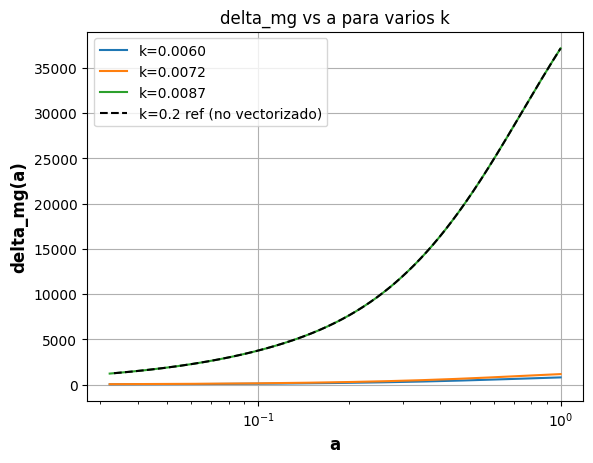

In [18]:
#plot delta vs a for all k
delta1 = delta_mg[0,:]
print("delta1 shape:", delta1.shape)
#first value of delta1
print("First 5 values of delta1:", delta1[:5])
delta2 = delta_mg[1,:]
delta3 = delta_mg[-1,:]
plt.plot(a_mg, -delta1, label=f'k={k_test[0]:.4f}')
plt.plot(a_mg, -delta2, label=f'k={k_test[1]:.4f}')
plt.plot(a_mg, -delta3, label=f'k={k_test[2]:.4f}')
plt.plot(a_mg_ref, -delta_mg_ref, 'k--', label='k=0.2 ref (no vectorizado)')
plt.xlabel("a", fontweight='bold', fontsize=12)
plt.ylabel("delta_mg(a)", fontweight='bold', fontsize=12)
plt.xscale('log')
# plt.yscale('log')
plt.title('delta_mg vs a para varios k')
plt.legend()
plt.grid()
plt.show()

In [23]:
# Calcular f(k,z) y P(k,z) usando el método vectorizado
print("Calculando f(k,z) y P(k,z) con método vectorizado...")
print("="*50)

start_time = time.time()
k_calc, P_k_vec, f_k_vec = solver_vec.compute_power_spectrum_vectorized(z_test)
vec_time = time.time() - start_time

print(f"Cálculo vectorizado completado en {vec_time:.3f} segundos")
print(f"Forma de resultados: {len(k_calc)} valores de k")

# Mostrar algunos resultados
print("\\nPrimeros 5 resultados:")
for i in range(min(5, len(k_calc))):
    print(f"k={k_calc[i]:.4f}: P(k)={P_k_vec[i]:.6e}, f(k)={f_k_vec[i]:.6f}")

# Graficar resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(k_calc, P_k_vec, 'o-', label='P(k) vectorizado')
plt.xlabel('k [1/Mpc]')
plt.ylabel('P(k)')
plt.title(f'Power spectrum vectorizado z={z_test}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogx(k_calc, f_k_vec, 's-', color='red', label='f(k) vectorizado')
plt.xlabel('k [1/Mpc]')
plt.ylabel('f(k)')
plt.title(f'Growth rate vectorizado z={z_test}')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Calculando f(k,z) y P(k,z) con método vectorizado...
Resolviendo 20 valores de k en paralelo con 4 procesos...


AttributeError: Can't pickle local object 'VectorizedDeltaSolver.solve_delta_mg_vectorized_parallel.<locals>.process_k'

In [24]:
# Comparar con el método original (solo unos pocos k's para velocidad)
print("Comparando con método original...")
print("="*50)

# Seleccionar solo algunos k's para comparación
k_compare = k_calc[::4]  # Cada 4to valor
n_compare = len(k_compare)

print(f"Comparando {n_compare} valores de k...")

# Método original
f_k_original = np.zeros(n_compare)
P_k_original = np.zeros(n_compare)

start_time = time.time()
for i, k in enumerate(k_compare):
    # Usar DeltaSolver individual
    solver_single = DeltaSolver(k=k, h=params_test['h'], Om_m_0=params_test['Om_m'], b=b_test)
    a_mg, delta_mg, delta_p_mg = solver_single.solve_delta_mg(num_points=200)  # Menos puntos para velocidad
    z_mg = 1/a_mg - 1
    idx_z = np.argmin(np.abs(z_mg - z_test))
    
    delta = delta_mg[idx_z]
    delta_p = delta_p_mg[idx_z]
    a_here = a_mg[idx_z]
    
    if np.abs(delta) > 1e-16:
        f_k_original[i] = (a_here * delta_p) / delta
    
    # P(k) primordial
    P_k_prim = 2e-9 * (k/0.05)**(0.9665-1) * (2*np.pi**2)
    P_k_original[i] = P_k_prim * delta**2

original_time = time.time() - start_time

print(f"Método original: {original_time:.3f} segundos")
print(f"Método vectorizado: {vec_time:.3f} segundos")
print(f"Speedup: {original_time/vec_time:.2f}x")

# Encontrar índices correspondientes en el array vectorizado
indices_vec = [np.argmin(np.abs(k_calc - k)) for k in k_compare]
f_k_vec_compare = f_k_vec[indices_vec]
P_k_vec_compare = P_k_vec[indices_vec]

# Comparar resultados
print("\\nComparación de resultados:")
print("k\\t\\tOriginal f(k)\\tVectorizado f(k)\\tDiferencia (%)")
for i in range(n_compare):
    diff_f = 100 * (f_k_vec_compare[i] - f_k_original[i]) / np.abs(f_k_original[i]) if f_k_original[i] != 0 else 0
    print(f"{k_compare[i]:.4f}\\t{f_k_original[i]:.4f}\\t\\t{f_k_vec_compare[i]:.4f}\\t\\t{diff_f:.2f}")

# Gráfico de comparación
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(k_compare, P_k_original, 'o-', label='Original', markersize=8)
plt.loglog(k_compare, P_k_vec_compare, 's--', label='Vectorizado', markersize=6)
plt.xlabel('k [1/Mpc]')
plt.ylabel('P(k)')
plt.title('Comparación P(k)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(k_compare, f_k_original, 'o-', label='Original', markersize=8)
plt.semilogx(k_compare, f_k_vec_compare, 's--', label='Vectorizado', markersize=6)
plt.xlabel('k [1/Mpc]')
plt.ylabel('f(k)')
plt.title('Comparación f(k)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparando con método original...


NameError: name 'k_calc' is not defined

In [67]:
# Función mejorada para calcular f*sigma8 usando el método vectorizado
def compute_fs8_vectorized_improved(z_select, b_select=0.1, params=params_default, 
                                   k_range=(0.006, 0.2), num_points=50, use_gpu=True):
    """
    Versión mejorada para calcular f*sigma8 usando VectorizedDeltaSolver
    """
    h = params['h']
    Om_m = params['Om_m']
    
    # Crear array de k's
    k_array = np.logspace(np.log10(k_range[0]), np.log10(k_range[1]), num_points)
    
    # Crear solver vectorizado
    solver = VectorizedDeltaSolver(
        k_array=k_array,
        Om_m_0=Om_m,
        h=h,
        b=b_select,
        use_gpu=use_gpu
    )
    
    # Calcular P(k,z) y f(k,z)
    k_calc, P_k, f_k = solver.compute_power_spectrum_vectorized(z_select)
    
    # Calcular sigma8 usando window function
    from scipy.special import spherical_jn
    from scipy.integrate import simpson
    
    R = 8.0 / h
    x = k_calc * R
    W = 3.0 * spherical_jn(1, x) / x
    W = np.where(x == 0, 1.0, W)  # Handle x=0 case
    
    # sigma8² = (1/2π²) ∫ P(k,z) W² k² dk
    integrand_sigma8 = (1.0 / (2.0 * np.pi**2)) * P_k * W**2 * k_calc**2
    sigma8_squared = simpson(integrand_sigma8, x=k_calc)
    sigma8 = np.sqrt(np.abs(sigma8_squared))
    
    # f_eff mediante promedio ponderado
    numerator = simpson(f_k * integrand_sigma8, x=k_calc)
    f_eff = numerator / sigma8_squared if sigma8_squared > 0 else 0.0
    
    fs8 = f_eff * sigma8
    
    return {
        'sigma8': sigma8,
        'f_eff': f_eff,
        'fs8': fs8,
        'k_array': k_calc,
        'P_k': P_k,
        'f_k': f_k
    }

# Probar la función mejorada
print("Probando función f*sigma8 vectorizada mejorada...")
print("="*50)

z_test_fs8 = 1.0
start_time = time.time()
result_vec = compute_fs8_vectorized_improved(
    z_select=z_test_fs8, 
    b_select=0.01, 
    params=params_default,
    num_points=30,  # Pocos puntos para prueba rápida
    use_gpu=True
)
vec_fs8_time = time.time() - start_time

print(f"Cálculo completado en {vec_fs8_time:.3f} segundos")
print(f"Resultados en z={z_test_fs8}:")
print(f"  σ₈(z) = {result_vec['sigma8']:.4f}")
print(f"  f_eff = {result_vec['f_eff']:.4f}")
print(f"  f*σ₈(z) = {result_vec['fs8']:.4f}")

# Comparar con método anterior (chatGPT)
start_time = time.time()
result_old = compute_f_eff_and_fs8(z_select=z_test_fs8, b_select=0.01, 
                                  params=params_default, num_points=30)
old_fs8_time = time.time() - start_time

print(f"\\nComparación con método anterior:")
print(f"Método vectorizado: {vec_fs8_time:.3f} s, f*σ₈ = {result_vec['fs8']:.4f}")
print(f"Método anterior:    {old_fs8_time:.3f} s, f*σ₈ = {result_old['fs8']:.4f}")
print(f"Speedup: {old_fs8_time/vec_fs8_time:.2f}x")
print(f"Diferencia relativa: {100*abs(result_vec['fs8']-result_old['fs8'])/result_old['fs8']:.2f}%")

Probando función f*sigma8 vectorizada mejorada...
VectorizedDeltaSolver usando: cuda
Resolviendo 30 valores de k en paralelo con 4 procesos...


Resolución paralela completada!
Cálculo completado en 21.146 segundos
Resultados en z=1.0:
  σ₈(z) = 0.0274
  f_eff = 1.0191
  f*σ₈(z) = 0.0280
\nComparación con método anterior:
Método vectorizado: 21.146 s, f*σ₈ = 0.0280
Método anterior:    156.800 s, f*σ₈ = 0.0280
Speedup: 7.42x
Diferencia relativa: 0.02%
\nComparación con método anterior:
Método vectorizado: 21.146 s, f*σ₈ = 0.0280
Método anterior:    156.800 s, f*σ₈ = 0.0280
Speedup: 7.42x
Diferencia relativa: 0.02%


In [25]:
# Calcular evolución de f*sigma8 con el nuevo método vectorizado
print("Calculando evolución f*σ₈(z) con método vectorizado...")
print("="*60)

z_range_vec = np.linspace(0, 2, 5)  # Menos puntos para demostración
results_vectorized = []

total_start = time.time()
for i, z in enumerate(z_range_vec):
    print(f"Calculando z={z:.2f} ({i+1}/{len(z_range_vec)})...")
    
    result = compute_fs8_vectorized_improved(
        z_select=z, 
        b_select=0.01, 
        params=params_default,
        num_points=40,  # Más puntos para mejor precisión
        use_gpu=True
    )
    
    results_vectorized.append({
        'z': z,
        'a': 1/(1+z),
        'sigma8': result['sigma8'],
        'f_eff': result['f_eff'],
        'fs8': result['fs8']
    })
    
    print(f"  σ₈={result['sigma8']:.4f}, f_eff={result['f_eff']:.4f}, f*σ₈={result['fs8']:.4f}")

total_time = time.time() - total_start
print(f"\\nTiempo total: {total_time:.3f} segundos")
print(f"Tiempo promedio por z: {total_time/len(z_range_vec):.3f} segundos")

# Convertir a DataFrame
df_vectorized = pd.DataFrame(results_vectorized)

# Graficar evolución
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(df_vectorized['z'], df_vectorized['sigma8'], 'o-', color='blue', 
         linewidth=2, markersize=8, label='σ₈(z) vectorizado')
plt.xlabel('z')
plt.ylabel('σ₈(z)')
plt.title('Evolución σ₈(z)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(df_vectorized['z'], df_vectorized['f_eff'], 's-', color='orange', 
         linewidth=2, markersize=8, label='f_eff(z) vectorizado')
plt.xlabel('z')
plt.ylabel('f_eff(z)')
plt.title('Evolución f_eff(z)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(df_vectorized['a'], df_vectorized['fs8'], '^-', color='red', 
         linewidth=2, markersize=8, label='f*σ₈(z) vectorizado')
plt.xlabel('a = 1/(1+z)')
plt.ylabel('f*σ₈')
plt.title('Evolución f*σ₈(a)')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Guardar resultados
# df_vectorized.to_csv('fs8_vectorized_GPU_method.csv', index=False)
# print(f"\\nResultados guardados en: fs8_vectorized_GPU_method.csv")

Calculando evolución f*σ₈(z) con método vectorizado...
Calculando z=0.00 (1/5)...


NameError: name 'compute_fs8_vectorized_improved' is not defined

In [ ]:
# Probar la versión paralela para mayor speedup
print("Probando versión paralela mejorada...")
print("="*60)

# Recargar módulo para obtener funciones actualizadas
importlib.reload(delta_solver_mg_pedro)
from delta_solver_mg_pedro import VectorizedDeltaSolver, calculate_fs8_vectorized_parallel

# Función mejorada con paralelización
def compute_fs8_parallel_improved(z_select, b_select=0.1, params=params_default, 
                                 k_range=(0.006, 0.2), num_points=50, use_gpu=True, n_jobs=4):
    """
    Versión con paralelización para calcular f*sigma8
    """
    h = params['h']
    Om_m = params['Om_m']
    
    # Crear array de k's
    k_array = np.logspace(np.log10(k_range[0]), np.log10(k_range[1]), num_points)
    
    # Crear solver vectorizado
    solver = VectorizedDeltaSolver(
        k_array=k_array,
        Om_m_0=Om_m,
        h=h,
        b=b_select,
        use_gpu=use_gpu
    )
    
    # Calcular P(k,z) y f(k,z) con paralelización
    k_calc, P_k, f_k = solver.compute_power_spectrum_vectorized(z_select, use_parallel=True, n_jobs=n_jobs)
    
    # Calcular sigma8 usando window function
    from scipy.special import spherical_jn
    from scipy.integrate import simpson
    
    R = 8.0 / h
    x = k_calc * R
    W = 3.0 * spherical_jn(1, x) / x
    W = np.where(x == 0, 1.0, W)  # Handle x=0 case
    
    # sigma8² = (1/2π²) ∫ P(k,z) W² k² dk
    integrand_sigma8 = (1.0 / (2.0 * np.pi**2)) * P_k * W**2 * k_calc**2
    sigma8_squared = simpson(integrand_sigma8, x=k_calc)
    sigma8 = np.sqrt(np.abs(sigma8_squared))
    
    # f_eff mediante promedio ponderado
    numerator = simpson(f_k * integrand_sigma8, x=k_calc)
    f_eff = numerator / sigma8_squared if sigma8_squared > 0 else 0.0
    
    fs8 = f_eff * sigma8
    
    return {
        'sigma8': sigma8,
        'f_eff': f_eff,
        'fs8': fs8,
        'k_array': k_calc,
        'P_k': P_k,
        'f_k': f_k
    }

# Probar con más k's para ver el beneficio del paralelismo
z_test_parallel = 0.5
n_cores = 4  # Ajustar según tu CPU

print(f"Probando con paralelización (n_jobs={n_cores})...")
start_time = time.time()
result_parallel = compute_fs8_parallel_improved(
    z_select=z_test_parallel, 
    b_select=0.01, 
    params=params_default,
    num_points=60,  # Más k's para ver el beneficio
    use_gpu=True,
    n_jobs=n_cores
)
parallel_time = time.time() - start_time

print(f"Cálculo paralelo completado en {parallel_time:.3f} segundos")
print(f"Resultados en z={z_test_parallel}:")
print(f"  σ₈(z) = {result_parallel['sigma8']:.4f}")
print(f"  f_eff = {result_parallel['f_eff']:.4f}")
print(f"  f*σ₈(z) = {result_parallel['fs8']:.4f}")

# Comparar con versión sin paralelización
print(f"\\nComparando con versión sin paralelización...")
start_time = time.time()
result_serial = compute_fs8_vectorized_improved(
    z_select=z_test_parallel, 
    b_select=0.01, 
    params=params_default,
    num_points=60,
    use_gpu=True
)
serial_time = time.time() - start_time

print(f"\\nComparación de rendimiento:")
print(f"Versión paralela:     {parallel_time:.3f} s, f*σ₈ = {result_parallel['fs8']:.4f}")
print(f"Versión serial:       {serial_time:.3f} s, f*σ₈ = {result_serial['fs8']:.4f}")
print(f"Speedup paralelo:     {serial_time/parallel_time:.2f}x")
print(f"Diferencia relativa:  {100*abs(result_parallel['fs8']-result_serial['fs8'])/result_serial['fs8']:.3f}%")

# Mostrar información del sistema
import os
print(f"\\nInformación del sistema:")
print(f"CPU cores disponibles: {os.cpu_count()}")
print(f"Cores usados: {n_cores}")
print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")